In [24]:
import pandas as pd
from pathlib import Path

BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\news_final")

files = {
    "+1 min":  BASE / "mega_final1.csv",
    "+5 min":  BASE / "mega_final5.csv",
    "+30 min": BASE / "mega_final30.csv",
}

# Correct informative columns in Mega Final
informative_cols = [
    "news_Guidance___Outlook_count",
    "news_M&A___Deal_count",
    "news_Product_News_count",
    "news_Regulatory_Approval_count",
    "news_Analyst___Rating_count",
    "news_Management___Legal_count",
    "news_Dividends___Buybacks_count",
    "news_Financing___Capital_count"
]

# MarketBeat / Earnings columns
MB_KEY_COLS = ["SUE_EPS", "SUR_Rev", "EPS_Surprise", "Revenue_Surprise"]

results = []

for label, path in files.items():
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df[df["Date"].dt.year.between(2016, 2023)].copy()
    df["gap_key"] = df["symbol"].str.upper() + "_" + df["Date"].dt.strftime("%Y-%m-%d")
    
    # --- Dynamic event_type assignment ---
    df["is_earnings"] = (df["gap_category"]=="Earnings") | df[MB_KEY_COLS].notna().any(axis=1) | (df.get("news_Earnings_count",0) > 0)
    df["inf_news_count"] = df[informative_cols].sum(axis=1) if all(col in df.columns for col in informative_cols) else 0
    
    df["FINAL_CATEGORY"] = "No-news"
    df.loc[(~df["is_earnings"]) & (df["inf_news_count"]>0), "FINAL_CATEGORY"] = "News"
    df.loc[df["is_earnings"], "FINAL_CATEGORY"] = "Earnings"
    
    # --- Compute counts ---
    total_gaps = df["gap_key"].nunique()
    counts = df.groupby("FINAL_CATEGORY")["gap_key"].nunique().to_dict()
    n_earnings = counts.get("Earnings",0)
    n_news = counts.get("News",0)
    n_nonews = counts.get("No-news",0)
    
    results.append({
        "Objemový filtr": label,
        "Celkem gapů": total_gaps,
        "Earnings gaps": n_earnings,
        "% Earnings": round(n_earnings / total_gaps * 100, 2),
        "News gaps": n_news,
        "% News": round(n_news / total_gaps * 100, 2),
        "No-news gaps": n_nonews,
        "% No-news": round(n_nonews / total_gaps * 100, 2),
    })

summary = pd.DataFrame(results)

print(summary.to_string(index=False))

# Save
summary.to_csv(BASE / "STATISTIKY_MEGA_FINAL_DYNAMIC_LOGIC.csv",
               index=False, encoding="utf-8-sig")


Objemový filtr  Celkem gapů  Earnings gaps  % Earnings  News gaps  % News  No-news gaps  % No-news
        +1 min         6802            638        9.38        933   13.72          5231      76.90
        +5 min         8787           1070       12.18       1157   13.17          6560      74.66
       +30 min         9975           1609       16.13       1339   13.42          7027      70.45


In [40]:
import pandas as pd
from pathlib import Path

BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\news_final")

# Input files for horizons
files = {
    "plus1": BASE / "mega_final1.csv",
    "plus5": BASE / "mega_final5.csv",
    "plus30": BASE / "mega_final30.csv",
}

# Columns for quartiles
metric_cols = ["SUE_EPS", "SUR_Rev", "Revenue_Surprise", "EPS_Surprise", "SUE_SUR"]

# Output folder
OUT_DIR = BASE / "quartiles"
OUT_DIR.mkdir(exist_ok=True)

for horizon, path in files.items():
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df[df["Date"].dt.year.between(2016, 2023)].copy()
    df["symbol"] = df["symbol"].astype(str).str.upper()

    # --- Add SUE_SUR column (simple average) ---
    if "SUE_EPS" in df.columns and "SUR_Rev" in df.columns:
        df["SUE_SUR"] = (df["SUE_EPS"] + df["SUR_Rev"]) / 2
    else:
        print(f"WARNING: Cannot compute SUE_SUR in {path.name}")

    for col in metric_cols:
        if col not in df.columns:
            print(f"Warning: {col} not found in {path.name}, skipping.")
            continue
        
        # Drop NaN rows
        df_col = df.dropna(subset=[col]).copy()
        if df_col.empty:
            continue
        
        # Assign QUARTILES (1 = lowest, 4 = highest)
        df_col[f"{col}_quartile"] = pd.qcut(df_col[col], 4, labels=False) + 1
        
        # Save each quartile into its own CSV
        for q in range(1, 5):  # quartiles = 4
            df_q = df_col[df_col[f"{col}_quartile"] == q].copy()
            if not df_q.empty:
                out_file = OUT_DIR / f"{horizon}_{col}_Q{q}.csv"
                df_q.to_csv(out_file, index=False, encoding="utf-8-sig")
                print(f"Saved {len(df_q)} rows to {out_file.name}")


Saved 29 rows to plus1_SUE_EPS_Q1.csv
Saved 29 rows to plus1_SUE_EPS_Q2.csv
Saved 29 rows to plus1_SUE_EPS_Q3.csv
Saved 29 rows to plus1_SUE_EPS_Q4.csv
Saved 23 rows to plus1_SUR_Rev_Q1.csv
Saved 23 rows to plus1_SUR_Rev_Q2.csv
Saved 23 rows to plus1_SUR_Rev_Q3.csv
Saved 23 rows to plus1_SUR_Rev_Q4.csv
Saved 30 rows to plus1_Revenue_Surprise_Q1.csv
Saved 30 rows to plus1_Revenue_Surprise_Q2.csv
Saved 29 rows to plus1_Revenue_Surprise_Q3.csv
Saved 30 rows to plus1_Revenue_Surprise_Q4.csv
Saved 37 rows to plus1_EPS_Surprise_Q1.csv
Saved 36 rows to plus1_EPS_Surprise_Q2.csv
Saved 36 rows to plus1_EPS_Surprise_Q3.csv
Saved 36 rows to plus1_EPS_Surprise_Q4.csv
Saved 22 rows to plus1_SUE_SUR_Q1.csv
Saved 21 rows to plus1_SUE_SUR_Q2.csv
Saved 21 rows to plus1_SUE_SUR_Q3.csv
Saved 22 rows to plus1_SUE_SUR_Q4.csv
Saved 77 rows to plus5_SUE_EPS_Q1.csv
Saved 77 rows to plus5_SUE_EPS_Q2.csv
Saved 76 rows to plus5_SUE_EPS_Q3.csv
Saved 77 rows to plus5_SUE_EPS_Q4.csv
Saved 70 rows to plus5_SUR_Rev_Q

In [41]:
# QUARTILES_STATS_FROM_EXISTING_CSVS.py
# → Popisné statistiky ze čtvrtin (Q1–Q4)
# → Výstup: CSV s deskriptivní statistikou

import pandas as pd
from pathlib import Path

# === TVOJE CESTA ===
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka")
QUART_BASE = BASE / "MAIN_DATAFRAME" / "news_final" / "quartiles"

horizons = ["plus1", "plus5", "plus30"]
horizon_names = {"plus1": "+1 min", "plus5": "+5 min", "plus30": "+30 min"}

# Mapování názvů metrik
metric_names = {
    "SUE_EPS": "SUE",
    "SUR_Rev": "SUR",
    "EPS_Surprise": "EPS %",
    "Revenue_Surprise": "Rev %",
    "SUE_SUR": "SUE+SUR"
}

results = []

for h in horizons:
    folder = QUART_BASE / h
    if not folder.exists():
        print(f"Chybí složka: {folder}")
        continue
    
    print(f"\n=== ZPRACOVÁVÁM: {horizon_names[h]} ===")
    
    for csv_file in folder.glob("*.csv"):
        if csv_file.name.startswith("._"):  # macOS hidden files
            continue
            
        df = pd.read_csv(csv_file)

        # example: plus30_SUE_EPS_Q1.csv → SUE_EPS
        parts = csv_file.stem.split("_")
        metric_col = "_".join(parts[1:-1])
        quartile = parts[-1]  # Q1, Q2, Q3, Q4
        
        if metric_col not in metric_names:
            continue
            
        if metric_col not in df.columns:
            continue
            
        valid = df[metric_col].dropna()
        if len(valid) == 0:
            continue
            
        stats = {
            "Horizon": horizon_names[h],
            "Metric": metric_names[metric_col],
            "Quartile": quartile,
            "N": len(valid),
            "Mean": valid.mean(),
            "Median": valid.median(),
            "Min": valid.min(),
            "Max": valid.max(),
            "Std": valid.std()
        }
        
        results.append(stats)
        
        print(f"{metric_names[metric_col]:>6} {quartile}: N={len(valid):>3} | "
              f"Mean={stats['Mean']:>8.4f} | Median={stats['Median']:>8.4f} | "
              f"Min={stats['Min']:>8.4f} | Max={stats['Max']:>8.4f}")

# === VÝSTUP ===
final = pd.DataFrame(results)
final = final.sort_values(["Horizon", "Metric", "Quartile"]).reset_index(drop=True)

# Zaokrouhlení
final[["Mean","Median","Min","Max","Std"]] = \
    final[["Mean","Median","Min","Max","Std"]].round(4)

# Uložení CSV
csv_out = BASE / "MAIN_DATAFRAME" / "QUARTILES_DESCRIPTIVE_STATS.csv"
final.to_csv(csv_out, index=False, encoding="utf-8-sig")

print("\n" + "="*80)
print("HOTOVO! Statistická tabulka kvartilů je připravena:")
print(csv_out)
print("="*80)
print("\nNáhled (+30 min):")
print(final[final["Horizon"] == "+30 min"].to_string(index=False))



=== ZPRACOVÁVÁM: +1 min ===
 EPS % Q1: N= 37 | Mean= -0.6631 | Median= -0.1500 | Min= -7.0000 | Max=  0.0952
 EPS % Q2: N= 36 | Mean=  0.2539 | Median=  0.2308 | Min=  0.0970 | Max=  0.4706
 EPS % Q3: N= 36 | Mean=  0.7962 | Median=  0.7143 | Min=  0.4897 | Max=  1.3750
 EPS % Q4: N= 36 | Mean=  4.6831 | Median=  2.9286 | Min=  1.4000 | Max= 17.0000
 Rev % Q1: N= 30 | Mean= -0.0927 | Median= -0.0494 | Min= -0.6286 | Max=  0.0169
 Rev % Q2: N= 30 | Mean=  0.0426 | Median=  0.0378 | Min=  0.0192 | Max=  0.0843
 Rev % Q3: N= 29 | Mean=  0.1371 | Median=  0.1266 | Min=  0.0854 | Max=  0.1987
 Rev % Q4: N= 30 | Mean=  1.7973 | Median=  0.5275 | Min=  0.2040 | Max= 28.6500
   SUE Q1: N= 29 | Mean= -0.6530 | Median= -0.2089 | Min= -7.9849 | Max=  0.0808
   SUE Q2: N= 29 | Mean=  0.4750 | Median=  0.5085 | Min=  0.0853 | Max=  0.8391
   SUE Q3: N= 29 | Mean=  1.4311 | Median=  1.4564 | Min=  0.8395 | Max=  2.1918
   SUE Q4: N= 29 | Mean=  4.6445 | Median=  3.7867 | Min=  2.3190 | Max=  8.7710

In [1]:
# =============================================================================
# CAR_CALC_AND_TTESTS_FINAL_QUARTILES.py
# Compute CARs for all quartile CSVs and run t-tests
# =============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import time
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

# ---------------- CONFIG ----------------
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka")
INTRADAY = BASE / "gap_trades"
MAIN_DF = BASE / "MAIN_DATAFRAME"

# kvartily místo kvintilů
QUART_BASE = MAIN_DF / "news_final" / "quartiles"

ENTRY_IDX = {"plus1": 1, "plus5": 6, "plus30": 31}
HORIZON_LABEL = {"plus1": "+1 min", "plus5": "+5 min", "plus30": "+30 min"}

WINDOWS = {
    "That day (gap→close)": 0,
    "[+1d, +5d]": 5,
    "[+1d, +10d]": 10,
    "[+1d, +22d]": 22,
    "[+1d, +60d]": 60   # ← změněno z 59 na 60
}

# ---------------- Helper functions ----------------
def build_daily_lookup(daily_df):
    daily_lookup = {}
    daily_grouped_dates = {}
    for sym, g in daily_df.groupby("symbol"):
        g_sorted = g.sort_values("Date")
        arr = g_sorted["Date"].values
        daily_grouped_dates[sym] = arr
        for d, price in zip(g_sorted["Date"], g_sorted["close_price"]):
            daily_lookup[(sym, pd.to_datetime(d))] = float(price)
    return daily_lookup, daily_grouped_dates


_intraday_cache = {}
def load_intraday_cached(path):
    if path in _intraday_cache:
        return _intraday_cache[path]
    try:
        df = pd.read_csv(path, parse_dates=["Datetime"], low_memory=False)
    except Exception:
        _intraday_cache[path] = None
        return None
    if "Datetime" not in df.columns or "Open" not in df.columns:
        _intraday_cache[path] = None
        return None
    df = df[["Datetime","Open"]].dropna().sort_values("Datetime").reset_index(drop=True)
    df = df[df["Datetime"].dt.time >= time(9,30)].reset_index(drop=True)
    _intraday_cache[path] = df
    return df


def find_trading_index(dates_arr, target_date_ts):
    if dates_arr is None or len(dates_arr) == 0:
        return None
    t64 = np.datetime64(pd.to_datetime(target_date_ts))
    idx = np.searchsorted(dates_arr, t64)
    if idx < len(dates_arr) and dates_arr[idx] == t64:
        return int(idx)
    if idx-1 >= 0 and dates_arr[idx-1] == t64:
        return int(idx-1)
    return None


intraday_letter_folder_cache = {
    p.name.split("_")[1].upper(): p
    for p in INTRADAY.iterdir()
    if p.is_dir() and p.name.lower().startswith("stock_")
}

_symbol_file_cache = {}
def get_intraday_path_for(sym, date_dt):
    key = (sym, date_dt.strftime("%Y-%m-%d"))
    if key in _symbol_file_cache:
        return _symbol_file_cache[key]
    folder = intraday_letter_folder_cache.get(sym[0].upper())
    if folder is None:
        _symbol_file_cache[key] = None
        return None
    fname = f"{sym}_{date_dt.strftime('%Y-%m-%d')}.csv"
    p = folder / fname
    if p.exists():
        _symbol_file_cache[key] = p
        return p
    matches = list(folder.glob(f"{sym}_{date_dt.strftime('%Y-%m-%d')}*.csv"))
    _symbol_file_cache[key] = matches[0] if matches else None
    return _symbol_file_cache[key]


# ---------------- 1) Load daily OHLC ----------------
daily_raw = pd.read_csv(MAIN_DF / "MAIN_DF_final.csv", low_memory=False)
daily_raw["Date"] = pd.to_datetime(daily_raw["Date"], errors="coerce")
daily_raw = daily_raw.dropna(subset=["Date"])
daily_raw["symbol"] = daily_raw["Ticker"].astype(str).str.upper()
daily_raw["close_price"] = daily_raw["Close"].astype(float)

daily = daily_raw[["symbol","Date","close_price"]].sort_values(
    ["symbol","Date"]
).reset_index(drop=True)

daily_lookup, daily_grouped = build_daily_lookup(daily)


# ---------------- 2) Compute CARs for all *quartile* CSVs ----------------
results = []

for horizon in ["plus1","plus5","plus30"]:
    folder = QUART_BASE / horizon
    if not folder.exists():
        print(f"Folder not found: {folder}")
        continue

    csv_files = list(folder.glob("*.csv"))
    print(f"Processing horizon: {horizon} -> {len(csv_files)} CSV files")

    for csv_path in csv_files:
        df = pd.read_csv(csv_path)
        if df.empty or "Date" not in df.columns or "symbol" not in df.columns:
            continue

        df["Date"] = pd.to_datetime(df["Date"])
        df["symbol"] = df["symbol"].astype(str).str.upper()

        fname = csv_path.stem
        parts = fname.split("_")
        metric = "_".join(parts[1:-1])  # SUE_EPS, SUR_Rev, EPS_Surprise...
        quartile = parts[-1]           # Q1, Q2, Q3, Q4

        accum = {w: [] for w in WINDOWS.keys()}
        entry_idx = ENTRY_IDX[horizon]

        for sym, edate in df[["symbol","Date"]].itertuples(index=False):

            pth = get_intraday_path_for(sym, edate)
            if pth is None:
                continue

            idf = load_intraday_cached(pth)
            if idf is None or len(idf) <= entry_idx:
                continue

            entry_price = idf.iloc[entry_idx]["Open"]
            if pd.isna(entry_price) or entry_price <= 0:
                continue

            dates_arr = daily_grouped.get(sym)
            if dates_arr is None:
                continue
            
            pos = find_trading_index(dates_arr, edate)
            if pos is None:
                continue

            for wname, offset in WINDOWS.items():
                exit_pos = pos + offset
                if exit_pos >= len(dates_arr):
                    continue

                exit_date = pd.to_datetime(dates_arr[exit_pos])
                exit_price = daily_lookup.get((sym, exit_date))

                if exit_price is None or exit_price <= 0:
                    continue

                ret = (exit_price / entry_price) - 1.0
                accum[wname].append(ret)

        row = {
            "Horizon": HORIZON_LABEL[horizon],
            "Metric": metric,
            "Quartile": quartile,
            "N_gaps": len(df)
        }

        for wname, vals in accum.items():
            if len(vals) >= 1:
                row[wname] = np.mean(vals) * 100
                row[wname+"_n"] = len(vals)
            else:
                row[wname] = None
                row[wname+"_n"] = 0

        row["_raw"] = accum
        results.append(row)


# ---------------- 3) Save CAR table ----------------
res_df = pd.DataFrame(results)
res_df_out = res_df.drop(columns=["_raw"])
out_path = MAIN_DF / "CAR_quartiles_results_clean.csv"

res_df_out.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"\nSaved CAR table (clean) to: {out_path}")

# ---------------- 3B) Save RAW CARs (one row = one trade) ----------------
raw_rows = []

for row in results:
    horizon = row["Horizon"]
    metric   = row["Metric"]
    quartile = row["Quartile"]
    raw_dict = row["_raw"]     # dict: {window → list of CARs}

    # reconstruct per-trade rows by aligning lists by index
    # first find max length
    max_len = max(len(v) for v in raw_dict.values())

    # pad shorter lists with None
    aligned = {
        w: (vals + [None]*(max_len - len(vals)))
        for w, vals in raw_dict.items()
    }

    for i in range(max_len):
        raw_rows.append({
            "Horizon": horizon,
            "Metric": metric,
            "Quartile": quartile,
            "CAR_0d": aligned["That day (gap→close)"][i],
            "CAR_5d": aligned["[+1d, +5d]"][i],
            "CAR_10d": aligned["[+1d, +10d]"][i],
            "CAR_22d": aligned["[+1d, +22d]"][i],
            "CAR_60d": aligned["[+1d, +60d]"][i]
        })

raw_df = pd.DataFrame(raw_rows)

raw_path = MAIN_DF / "CAR_quartiles_raw_long.csv"
raw_df.to_csv(raw_path, index=False, encoding="utf-8-sig")
print(f"Saved RAW CAR table to: {raw_path}")



# ---------------- 4) T-tests ----------------
ttest_results = []

for row in results:
    t_row = {
        "Horizon": row["Horizon"],
        "Metric": row["Metric"],
        "Quartile": row["Quartile"],
        "N_gaps": row["N_gaps"]
    }

    for wname in WINDOWS.keys():
        vals = row["_raw"].get(wname, [])
        if len(vals) >= 2:
            vals_pct = np.array(vals) * 100
            t_stat, p_val = stats.ttest_1samp(vals_pct, 0)
            t_row[f"{wname}_t"] = t_stat
            t_row[f"{wname}_p"] = p_val
        else:
            t_row[f"{wname}_t"] = None
            t_row[f"{wname}_p"] = None

    ttest_results.append(t_row)

ttest_df = pd.DataFrame(ttest_results)
ttest_out = MAIN_DF / "CAR_quartiles_ttests.csv"

ttest_df.to_csv(ttest_out, index=False, encoding="utf-8-sig")
print(f"T-tests saved to: {ttest_out}")
print(ttest_df.head(10).to_string(index=False))


C:\Users\j-vas\anaconda3\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Processing horizon: plus1 -> 20 CSV files
Processing horizon: plus5 -> 20 CSV files
Processing horizon: plus30 -> 20 CSV files

Saved CAR table (clean) to: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\CAR_quartiles_results_clean.csv
Saved RAW CAR table to: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\CAR_quartiles_raw_long.csv
T-tests saved to: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\CAR_quartiles_ttests.csv
Horizon           Metric Quartile  N_gaps  That day (gap→close)_t  That day (gap→close)_p  [+1d, +5d]_t  [+1d, +5d]_p  [+1d, +10d]_t  [+1d, +10d]_p  [+1d, +22d]_t  [+1d, +22d]_p  [+1d, +60d]_t  [+1d, +60d]_p
 +1 min     EPS_Surprise       Q1      37               -1.597163                0.118971      0.259405      0.796801       0.519883       0.606328       0.673075       0.505198       0.563852       0.576351
 +1 min     EPS_Surprise       Q2      36               -0.190357                0.850129     -0.409741      0.684493      -1.035736       0.307429  

In [10]:
# =============================================================================
# CAR_CALC_AND_TTESTS_FINAL_QUARTILES.py
# Compute CARs for all quartile CSVs and run t-tests
# =============================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import time
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

# ---------------- CONFIG ----------------
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka")
INTRADAY = BASE / "gap_trades"
MAIN_DF = BASE / "MAIN_DATAFRAME"

# kvartily místo kvintilů
QUART_BASE = MAIN_DF / "news_final" / "quartiles"

ENTRY_IDX = {"plus1": 1, "plus5": 6, "plus30": 31}
HORIZON_LABEL = {"plus1": "+1 min", "plus5": "+5 min", "plus30": "+30 min"}

WINDOWS = {
    "That day (gap→close)": 0,
    "[+1d, +5d]": 5,
    "[+1d, +10d]": 10,
    "[+1d, +22d]": 22,
    "[+1d, +60d]": 60   # ← změněno z 59 na 60
}

# ---------------- Helper functions ----------------
def build_daily_lookup(daily_df):
    daily_lookup = {}
    daily_grouped_dates = {}
    for sym, g in daily_df.groupby("symbol"):
        g_sorted = g.sort_values("Date")
        arr = g_sorted["Date"].values
        daily_grouped_dates[sym] = arr
        for d, price in zip(g_sorted["Date"], g_sorted["close_price"]):
            daily_lookup[(sym, pd.to_datetime(d))] = float(price)
    return daily_lookup, daily_grouped_dates


_intraday_cache = {}
def load_intraday_cached(path):
    if path in _intraday_cache:
        return _intraday_cache[path]
    try:
        df = pd.read_csv(path, parse_dates=["Datetime"], low_memory=False)
    except Exception:
        _intraday_cache[path] = None
        return None
    if "Datetime" not in df.columns or "Open" not in df.columns:
        _intraday_cache[path] = None
        return None
    df = df[["Datetime","Open"]].dropna().sort_values("Datetime").reset_index(drop=True)
    df = df[df["Datetime"].dt.time >= time(9,30)].reset_index(drop=True)
    _intraday_cache[path] = df
    return df


def find_trading_index(dates_arr, target_date_ts):
    if dates_arr is None or len(dates_arr) == 0:
        return None
    t64 = np.datetime64(pd.to_datetime(target_date_ts))
    idx = np.searchsorted(dates_arr, t64)
    if idx < len(dates_arr) and dates_arr[idx] == t64:
        return int(idx)
    if idx-1 >= 0 and dates_arr[idx-1] == t64:
        return int(idx-1)
    return None


intraday_letter_folder_cache = {
    p.name.split("_")[1].upper(): p
    for p in INTRADAY.iterdir()
    if p.is_dir() and p.name.lower().startswith("stock_")
}

_symbol_file_cache = {}
def get_intraday_path_for(sym, date_dt):
    key = (sym, date_dt.strftime("%Y-%m-%d"))
    if key in _symbol_file_cache:
        return _symbol_file_cache[key]
    folder = intraday_letter_folder_cache.get(sym[0].upper())
    if folder is None:
        _symbol_file_cache[key] = None
        return None
    fname = f"{sym}_{date_dt.strftime('%Y-%m-%d')}.csv"
    p = folder / fname
    if p.exists():
        _symbol_file_cache[key] = p
        return p
    matches = list(folder.glob(f"{sym}_{date_dt.strftime('%Y-%m-%d')}*.csv"))
    _symbol_file_cache[key] = matches[0] if matches else None
    return _symbol_file_cache[key]


# ---------------- 1) Load daily OHLC ----------------
daily_raw = pd.read_csv(MAIN_DF / "MAIN_DF_final.csv", low_memory=False)
daily_raw["Date"] = pd.to_datetime(daily_raw["Date"], errors="coerce")
daily_raw = daily_raw.dropna(subset=["Date"])
daily_raw["symbol"] = daily_raw["Ticker"].astype(str).str.upper()
daily_raw["close_price"] = daily_raw["Close"].astype(float)

daily = daily_raw[["symbol","Date","close_price"]].sort_values(
    ["symbol","Date"]
).reset_index(drop=True)

daily_lookup, daily_grouped = build_daily_lookup(daily)


# ---------------- 2) Compute CARs for all *quartile* CSVs ----------------
results = []

for horizon in ["plus1","plus5","plus30"]:
    folder = QUART_BASE / horizon
    if not folder.exists():
        print(f"Folder not found: {folder}")
        continue

    csv_files = list(folder.glob("*.csv"))
    print(f"Processing horizon: {horizon} -> {len(csv_files)} CSV files")

    for csv_path in csv_files:
        df = pd.read_csv(csv_path)
        if df.empty or "Date" not in df.columns or "symbol" not in df.columns:
            continue

        df["Date"] = pd.to_datetime(df["Date"])
        df["symbol"] = df["symbol"].astype(str).str.upper()

        fname = csv_path.stem
        parts = fname.split("_")
        metric = "_".join(parts[1:-1])
        quartile = parts[-1]

        # NEW: store CARs and also (symbol, date)
        accum = {w: [] for w in WINDOWS.keys()}
        accum_ids = {w: [] for w in WINDOWS.keys()}

        entry_idx = ENTRY_IDX[horizon]

        for sym, edate in df[["symbol","Date"]].itertuples(index=False):

            pth = get_intraday_path_for(sym, edate)
            if pth is None:
                continue

            idf = load_intraday_cached(pth)
            if idf is None or len(idf) <= entry_idx:
                continue

            entry_price = idf.iloc[entry_idx]["Open"]
            if pd.isna(entry_price) or entry_price <= 0:
                continue

            dates_arr = daily_grouped.get(sym)
            if dates_arr is None:
                continue

            pos = find_trading_index(dates_arr, edate)
            if pos is None:
                continue

            for wname, offset in WINDOWS.items():
                exit_pos = pos + offset
                if exit_pos >= len(dates_arr):
                    continue

                exit_date = pd.to_datetime(dates_arr[exit_pos])
                exit_price = daily_lookup.get((sym, exit_date))

                if exit_price is None or exit_price <= 0:
                    continue

                ret = (exit_price / entry_price) - 1.0

                accum[wname].append(ret)
                accum_ids[wname].append((sym, edate))   # <<<<<< NEW

        row = {
            "Horizon": HORIZON_LABEL[horizon],
            "Metric": metric,
            "Quartile": quartile,
            "N_gaps": len(df),
            "_raw": accum,
            "_ids": accum_ids   # <<<< NEW
        }

        results.append(row)



# ---------------- 3) Save CAR table ----------------
res_df = pd.DataFrame(results)
res_df_out = res_df.drop(columns=["_raw"])
out_path = MAIN_DF / "CAR_quartiles_results_clean.csv"

res_df_out.to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"\nSaved CAR table (clean) to: {out_path}")

# ---------------- 3B) Save RAW CARs (with symbol + date) ----------------
raw_rows = []

for row in results:
    horizon = row["Horizon"]
    metric   = row["Metric"]
    quartile = row["Quartile"]

    raw_dict = row["_raw"]
    id_dict  = row["_ids"]

    windows = list(WINDOWS.keys())
    max_len = max(len(raw_dict[w]) for w in windows)

    # pad
    for w in windows:
        L = len(raw_dict[w])
        if L < max_len:
            raw_dict[w] += [None] * (max_len - L)
            id_dict[w]  += [(None, None)] * (max_len - L)

    for i in range(max_len):

        # we take symbol/date from 0-day window (always exists if trade is valid)
        sym, dt = id_dict["That day (gap→close)"][i]

        raw_rows.append({
            "Horizon": horizon,
            "Metric": metric,
            "Quartile": quartile,
            "Symbol": sym,
            "Date": dt,
            "CAR_0d": raw_dict["That day (gap→close)"][i],
            "CAR_5d": raw_dict["[+1d, +5d]"][i],
            "CAR_10d": raw_dict["[+1d, +10d]"][i],
            "CAR_22d": raw_dict["[+1d, +22d]"][i],
            "CAR_60d": raw_dict["[+1d, +60d]"][i],
        })

raw_df = pd.DataFrame(raw_rows)
raw_path = MAIN_DF / "CAR_quartiles_raw_long.csv"
raw_df.to_csv(raw_path, index=False, encoding="utf-8-sig")
print(f"\nSaved RAW CAR table with symbol+date → {raw_path}")


# ---------------- 4) T-tests ----------------
ttest_results = []

for row in results:
    t_row = {
        "Horizon": row["Horizon"],
        "Metric": row["Metric"],
        "Quartile": row["Quartile"],
        "N_gaps": row["N_gaps"]
    }

    for wname in WINDOWS.keys():
        vals = row["_raw"].get(wname, [])
        if len(vals) >= 2:
            vals_pct = np.array(vals) * 100
            t_stat, p_val = stats.ttest_1samp(vals_pct, 0)
            t_row[f"{wname}_t"] = t_stat
            t_row[f"{wname}_p"] = p_val
        else:
            t_row[f"{wname}_t"] = None
            t_row[f"{wname}_p"] = None

    ttest_results.append(t_row)

ttest_df = pd.DataFrame(ttest_results)
ttest_out = MAIN_DF / "CAR_quartiles_ttests.csv"

ttest_df.to_csv(ttest_out, index=False, encoding="utf-8-sig")
print(f"T-tests saved to: {ttest_out}")
print(ttest_df.head(10).to_string(index=False))


Processing horizon: plus1 -> 20 CSV files
Processing horizon: plus5 -> 20 CSV files
Processing horizon: plus30 -> 20 CSV files

Saved CAR table (clean) to: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\CAR_quartiles_results_clean.csv

Saved RAW CAR table with symbol+date → C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\CAR_quartiles_raw_long.csv
T-tests saved to: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\CAR_quartiles_ttests.csv
Horizon           Metric Quartile  N_gaps  That day (gap→close)_t  That day (gap→close)_p  [+1d, +5d]_t  [+1d, +5d]_p  [+1d, +10d]_t  [+1d, +10d]_p  [+1d, +22d]_t  [+1d, +22d]_p  [+1d, +60d]_t  [+1d, +60d]_p
 +1 min     EPS_Surprise       Q1      37               -1.597163                0.118971      0.259405      0.796801       0.519883       0.606328       0.673075       0.505198       0.563852       0.576351
 +1 min     EPS_Surprise       Q2      36               -0.190357                0.850129     -0.409741      0.684493      -1.035736 

In [ ]:
import pandas as pd
from pathlib import Path

BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME")

# Load processed CAR results and t-test statistics
car = pd.read_csv(BASE / "CAR_quartiles_results_clean.csv")   # ← updated
ttest = pd.read_csv(BASE / "CAR_quartiles_ttests.csv")        # ← updated

# Event windows
windows = [
    "That day (gap→close)",
    "[+1d, +5d]",
    "[+1d, +10d]",
    "[+1d, +22d]",
    "[+1d, +60d]"
]

# Merge CAR + t-tests
car = car.merge(
    ttest,
    on=["Horizon", "Metric", "Quartile"],   # ← changed Quintile → Quartile
    suffixes=("", "_p")
)

# Function for stars
def stars(p):
    if pd.isna(p): return ""
    if p < 0.01: return "***"
    if p < 0.05: return "**"
    if p < 0.10: return "*"
    return ""

# Append stars for each window
for w in windows:
    car[w] = car[w].round(3).astype(str) + car[f"{w}_p"].apply(stars)

# Clean table: drop *_n and *_p technical columns
drop_cols = [c for c in car.columns if c.endswith("_n") or c.endswith("_p")]
car = car.drop(columns=drop_cols)

# Save final results
final_out = BASE / "CAR_quartiles_FINAL_WITH_STARS.csv"
car.to_csv(final_out, index=False, encoding="utf-8-sig")

print("FINÁLNÍ TABULKA S HVĚZDIČKAMI (KVARTILY) ULOŽENA:")
print(final_out)


In [53]:
car.head(50)

,Horizon,Metric,Quartile,N_gaps,That day (gap→close),"[+1d, +5d]","[+1d, +10d]","[+1d, +22d]","[+1d, +60d]",That day (gap→close)_t,"[+1d, +5d]_t","[+1d, +10d]_t","[+1d, +22d]_t","[+1d, +60d]_t"
0,+1 min,EPS_Surprise,Q1,37,-3.344,1.212,2.539,3.706,6.521,-1.597163,0.259405,0.519883,0.673075,0.563852
1,+1 min,EPS_Surprise,Q2,36,-0.338,-1.111,-3.301,-1.417,34.018**,-0.190357,-0.409741,-1.035736,-0.371904,2.174983
2,+1 min,EPS_Surprise,Q3,36,2.97,1.17,4.651,3.549,11.123,0.650766,0.278652,0.913233,0.518571,1.418318
3,+1 min,EPS_Surprise,Q4,36,-1.168,3.802,9.784,13.605,17.692,-0.588431,0.901643,1.155038,1.554247,1.593141
4,+1 min,Revenue_Surprise,Q1,30,0.76,-3.773,-6.423,-2.943,21.742,0.326812,-1.039898,-1.616801,-0.606336,1.145989
5,+1 min,Revenue_Surprise,Q2,30,-1.954,-1.057,0.874,4.356,11.395,-1.085977,-0.315465,0.165551,0.468632,1.348968
6,+1 min,Revenue_Surprise,Q3,29,-3.811*,-2.299,0.476,3.315,11.753,-1.878818,-0.519940,0.085393,0.505754,1.321818
7,+1 min,Revenue_Surprise,Q4,30,2.305,10.323**,14.448,12.839,27.942**,1.062153,2.194708,1.548265,1.582706,2.175033
8,+1 min,SUE_EPS,Q1,29,-4.673*,-2.557,-3.593,-2.132,4.748,-1.937238,-0.504637,-0.654016,-0.383647,0.351647
9,+1 min,SUE_EPS,Q2,29,-1.2,-0.641,-2.378,-0.922,27.523,-0.515594,-0.198215,-0.727186,-0.263855,1.468664


In [81]:
# =============================================================================
# FINAL_BAR_CHARTS_QUARTILES_RED_BLUE_QUARTILE_SHADE.py
# → Quartile CAR charts: red shades indicate quartile (Q1–Q4),
#   very light blue for insignificant results
# → Stars preserved
# → CAR window definition explicitly stated in title
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import Patch

# === FILES ===
CSV_IN = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\CAR_quartiles_FINAL_WITH_STARS.csv")
OUT_DIR = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\charts_quartiles_redblue")
OUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(CSV_IN)

# === EVENT WINDOWS ===
windows = [
    "That day (gap→close)",
    "[+1d, +5d]",
    "[+1d, +10d]",
    "[+1d, +22d]",
    "[+1d, +60d]"
]
window_labels = ["That day", "+1 to +5d", "+1 to +10d", "+1 to +22d", "+1 to +60d"]

# === COLORS ===
# Red shades for quartiles Q1–Q4 (light → dark)
QUARTILE_COLORS = ["#FFCCCC", "#FF6666", "#CC0000", "#990000"]

# Very light blue for insignificant (no stars)
LIGHT_BLUE = "#DCEEFF"

print("Vytvářím grafy pro kvartily (red shading per quartile / very light blue for insignificant)...")

# === MAIN LOOP ===
for horizon in df["Horizon"].unique():
    data = df[df["Horizon"] == horizon].copy()
    data["Quartile"] = pd.Categorical(
        data["Quartile"],
        categories=["Q1", "Q2", "Q3", "Q4"],
        ordered=True
    )
    data = data.sort_values(["Metric", "Quartile"])

    metrics = data["Metric"].unique()

    fig, axes = plt.subplots(
        len(metrics),
        1,
        figsize=(14, 3.8 * len(metrics)),
        sharex=True
    )
    if len(metrics) == 1:
        axes = [axes]

    # === TITLE WITH EXPLICIT CAR WINDOW DEFINITION ===
    fig.suptitle(
        f"Cumulative Abnormal Returns by Quartile — {horizon}\n"
        "Event windows: same-day (open→close), post-event [+1d, +Xd]",
        fontsize=20,
        fontweight="bold",
        y=0.98
    )

    x = np.arange(len(window_labels))
    width = 0.18

    # === PLOT EACH METRIC ===
    for ax_idx, metric in enumerate(metrics):
        ax = axes[ax_idx]
        sub = data[data["Metric"] == metric]

        for _, row in sub.iterrows():
            q_idx = ["Q1", "Q2", "Q3", "Q4"].index(row["Quartile"])

            values = []
            stars = []
            colors = []

            for w in windows:
                val_str = str(row[w])

                clean = (
                    val_str.replace("***", "")
                           .replace("**", "")
                           .replace("*", "")
                           .strip()
                )
                num_val = float(clean) if clean not in ["", "-", "nan"] else 0.0
                values.append(num_val)

                # Stars
                if "***" in val_str:
                    stars.append("***")
                elif "**" in val_str:
                    stars.append("**")
                elif "*" in val_str:
                    stars.append("*")
                else:
                    stars.append("")

                # Color logic
                colors.append(
                    QUARTILE_COLORS[q_idx] if stars[-1] else LIGHT_BLUE
                )

            # === BARS ===
            bars = ax.bar(
                x + (q_idx - 1.5) * width,
                values,
                width,
                color=colors,
                edgecolor="black",
                linewidth=0.9
            )

            # === SIGNIFICANCE STARS ===
            for bar, star, val in zip(bars, stars, values):
                if star:
                    y_pos = (
                        val + 0.01 * abs(val)
                        if val >= 0
                        else val - 0.03 * abs(val)
                    )
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        y_pos,
                        star,
                        ha="center",
                        va="bottom" if val >= 0 else "top",
                        fontsize=11,
                        fontweight="bold",
                        color="black"
                    )

        ax.set_title(metric, fontsize=15, fontweight="bold", pad=18)
        ax.set_ylabel("CAR (%)", fontsize=12)
        ax.axhline(0, color="black", linewidth=1)
        ax.grid(True, axis="y", alpha=0.3, linestyle="--")

    # === SINGLE LEGEND ON THE RIGHT ===
    legend_elements = (
        [Patch(facecolor=LIGHT_BLUE, label="Not significant (no stars)")]
        + [
            Patch(facecolor=QUARTILE_COLORS[i], label=f"Quartile Q{i+1}")
            for i in range(4)
        ]
    )

    fig.legend(
        handles=legend_elements,
        title="Quartile / Significance",
        bbox_to_anchor=(1.02, 0.5),
        loc="center"
    )

    # === X-AXIS ===
    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(window_labels, fontsize=12)

    plt.tight_layout(rect=[0, 0.03, 0.95, 0.96])

    # === SAVE ===
    fname = f"CAR_Quartiles_RedBlue_{horizon.replace(' ', '').replace('+', '')}"
    plt.savefig(OUT_DIR / f"{fname}.png", dpi=300, bbox_inches="tight")
    plt.savefig(OUT_DIR / f"{fname}.pdf", bbox_inches="tight")
    plt.close()

    print(f"Uloženo: {fname}")

print("\nHOTOVO! Všechny grafy najdeš zde:")
print(OUT_DIR)


Vytvářím grafy pro kvartily (red shading per quartile / very light blue for insignificant)...
Uloženo: CAR_Quartiles_RedBlue_1min
Uloženo: CAR_Quartiles_RedBlue_5min
Uloženo: CAR_Quartiles_RedBlue_30min

HOTOVO! Všechny grafy najdeš zde:
C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\charts_quartiles_redblue


Nalezeno 3 grafů. Zobrazuji:

Soubor: CAR_Quartiles_RedBlue_1min.png


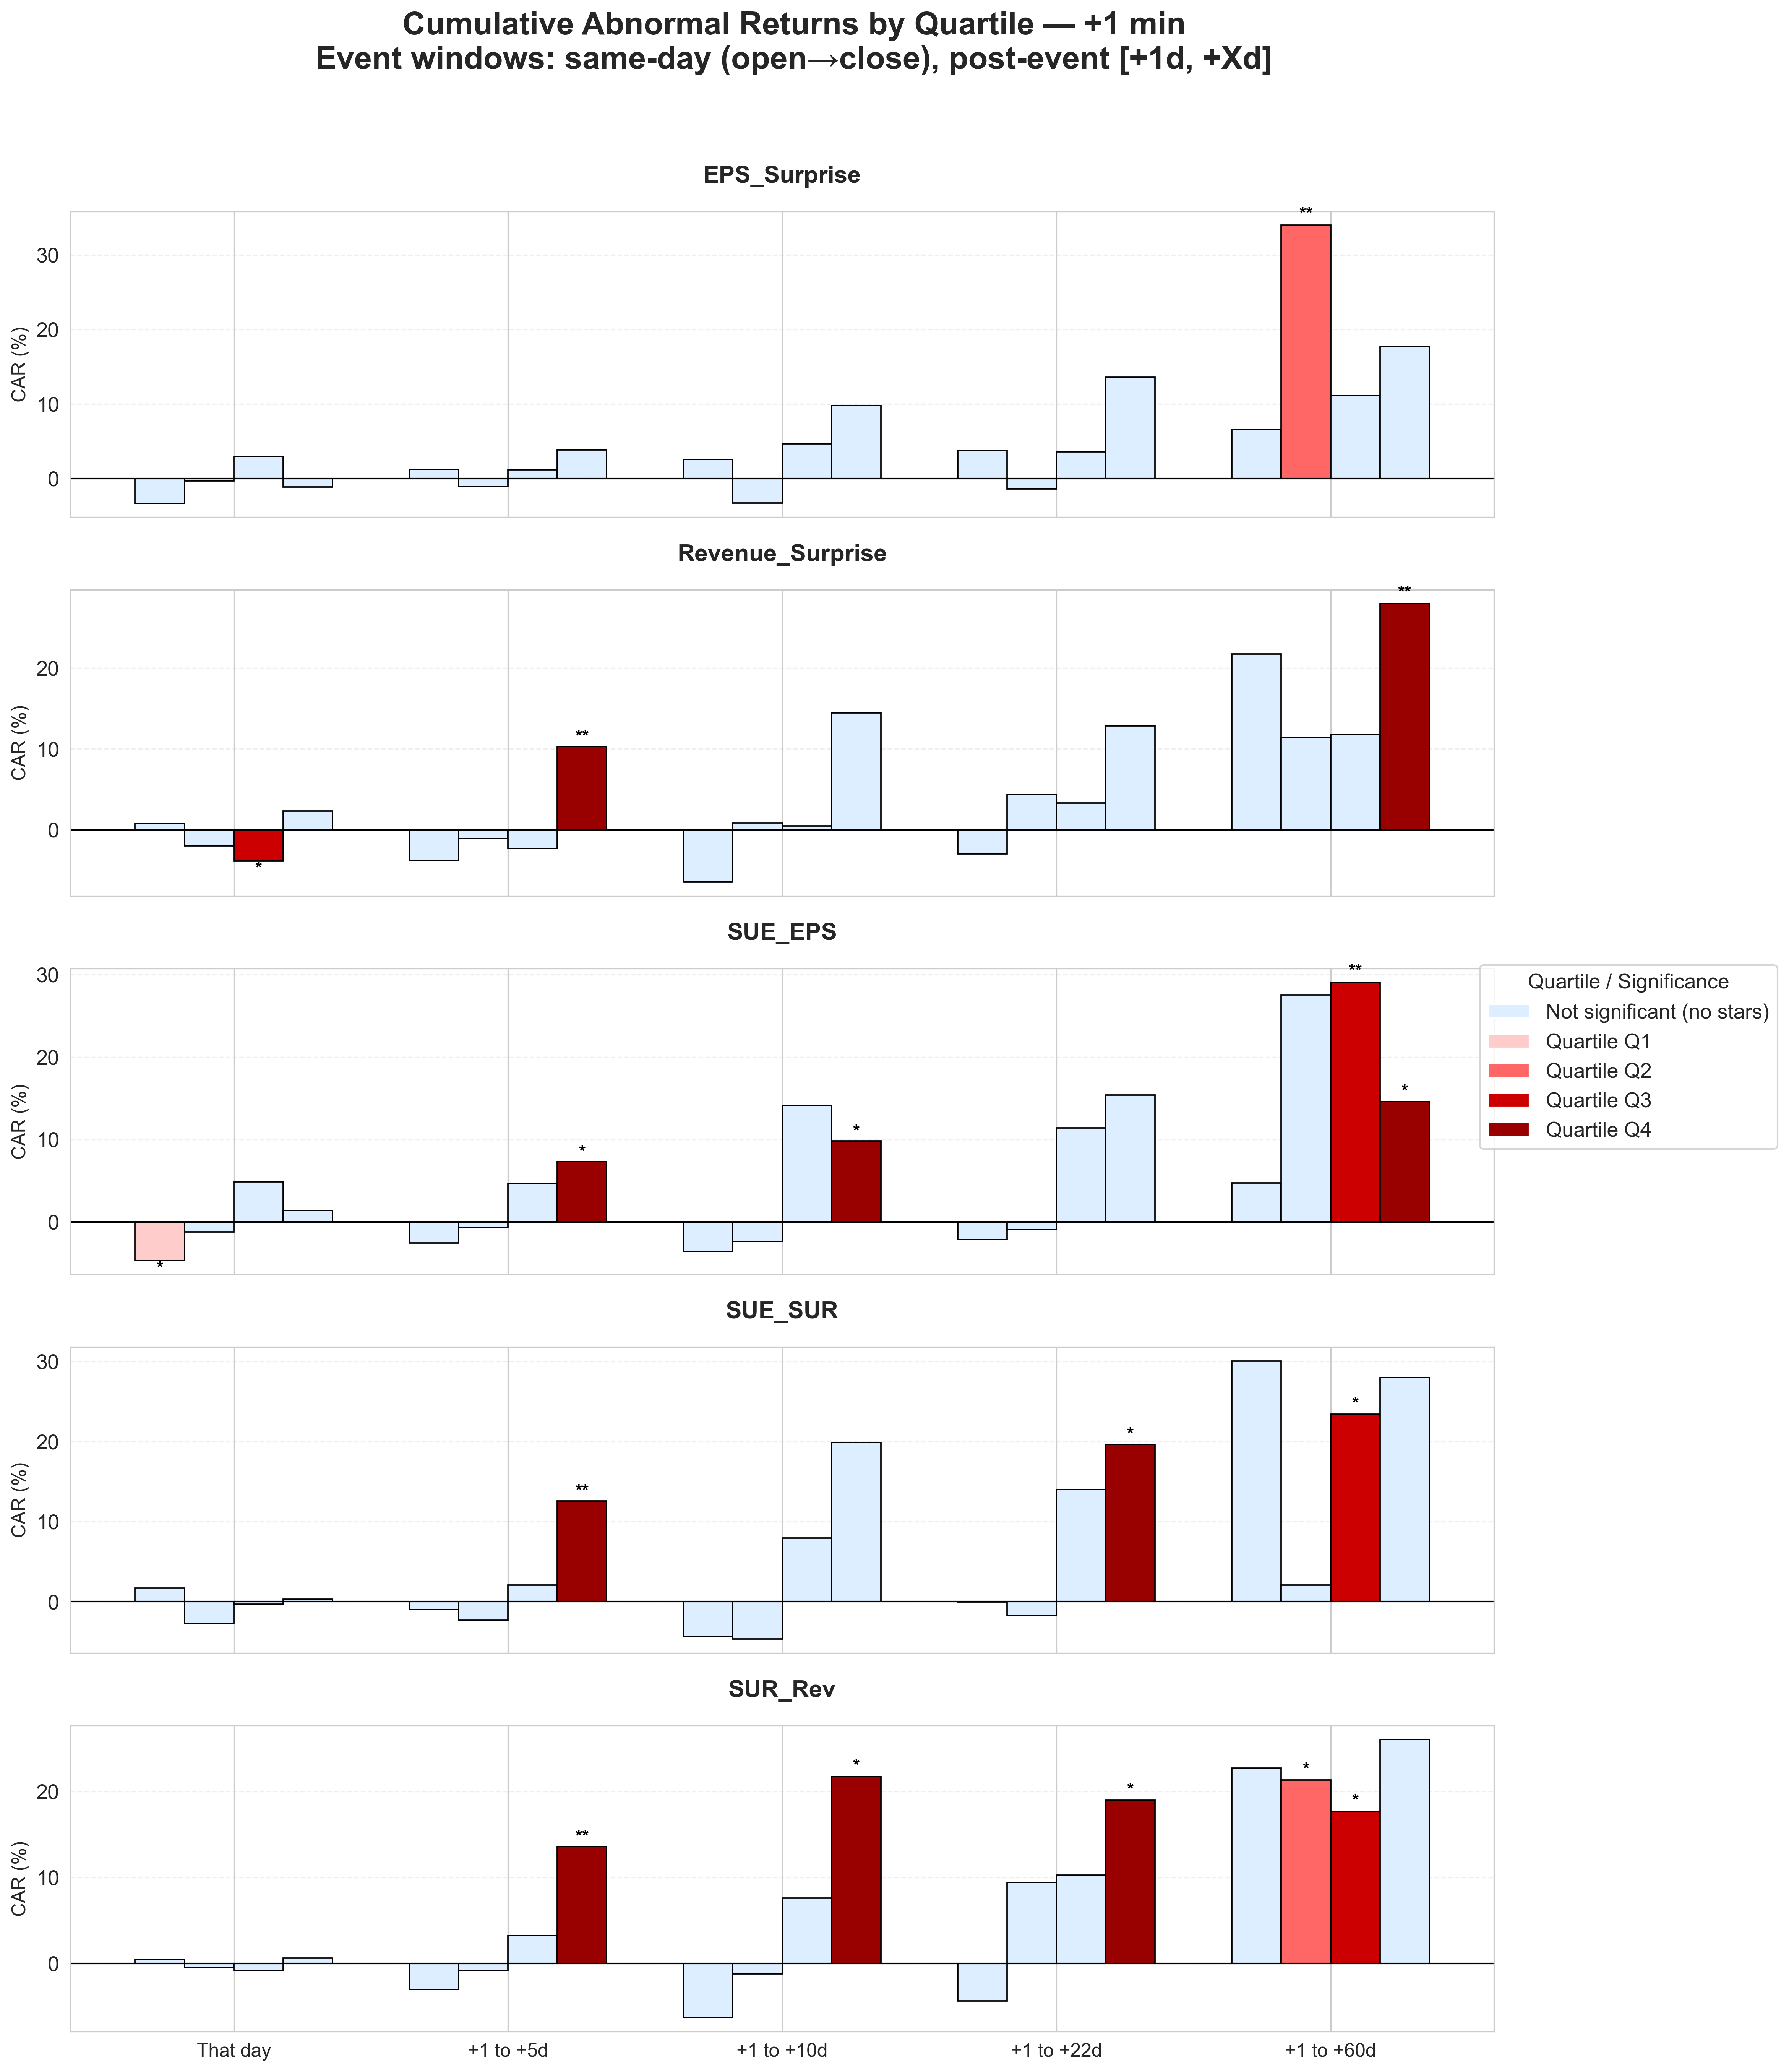


Soubor: CAR_Quartiles_RedBlue_30min.png


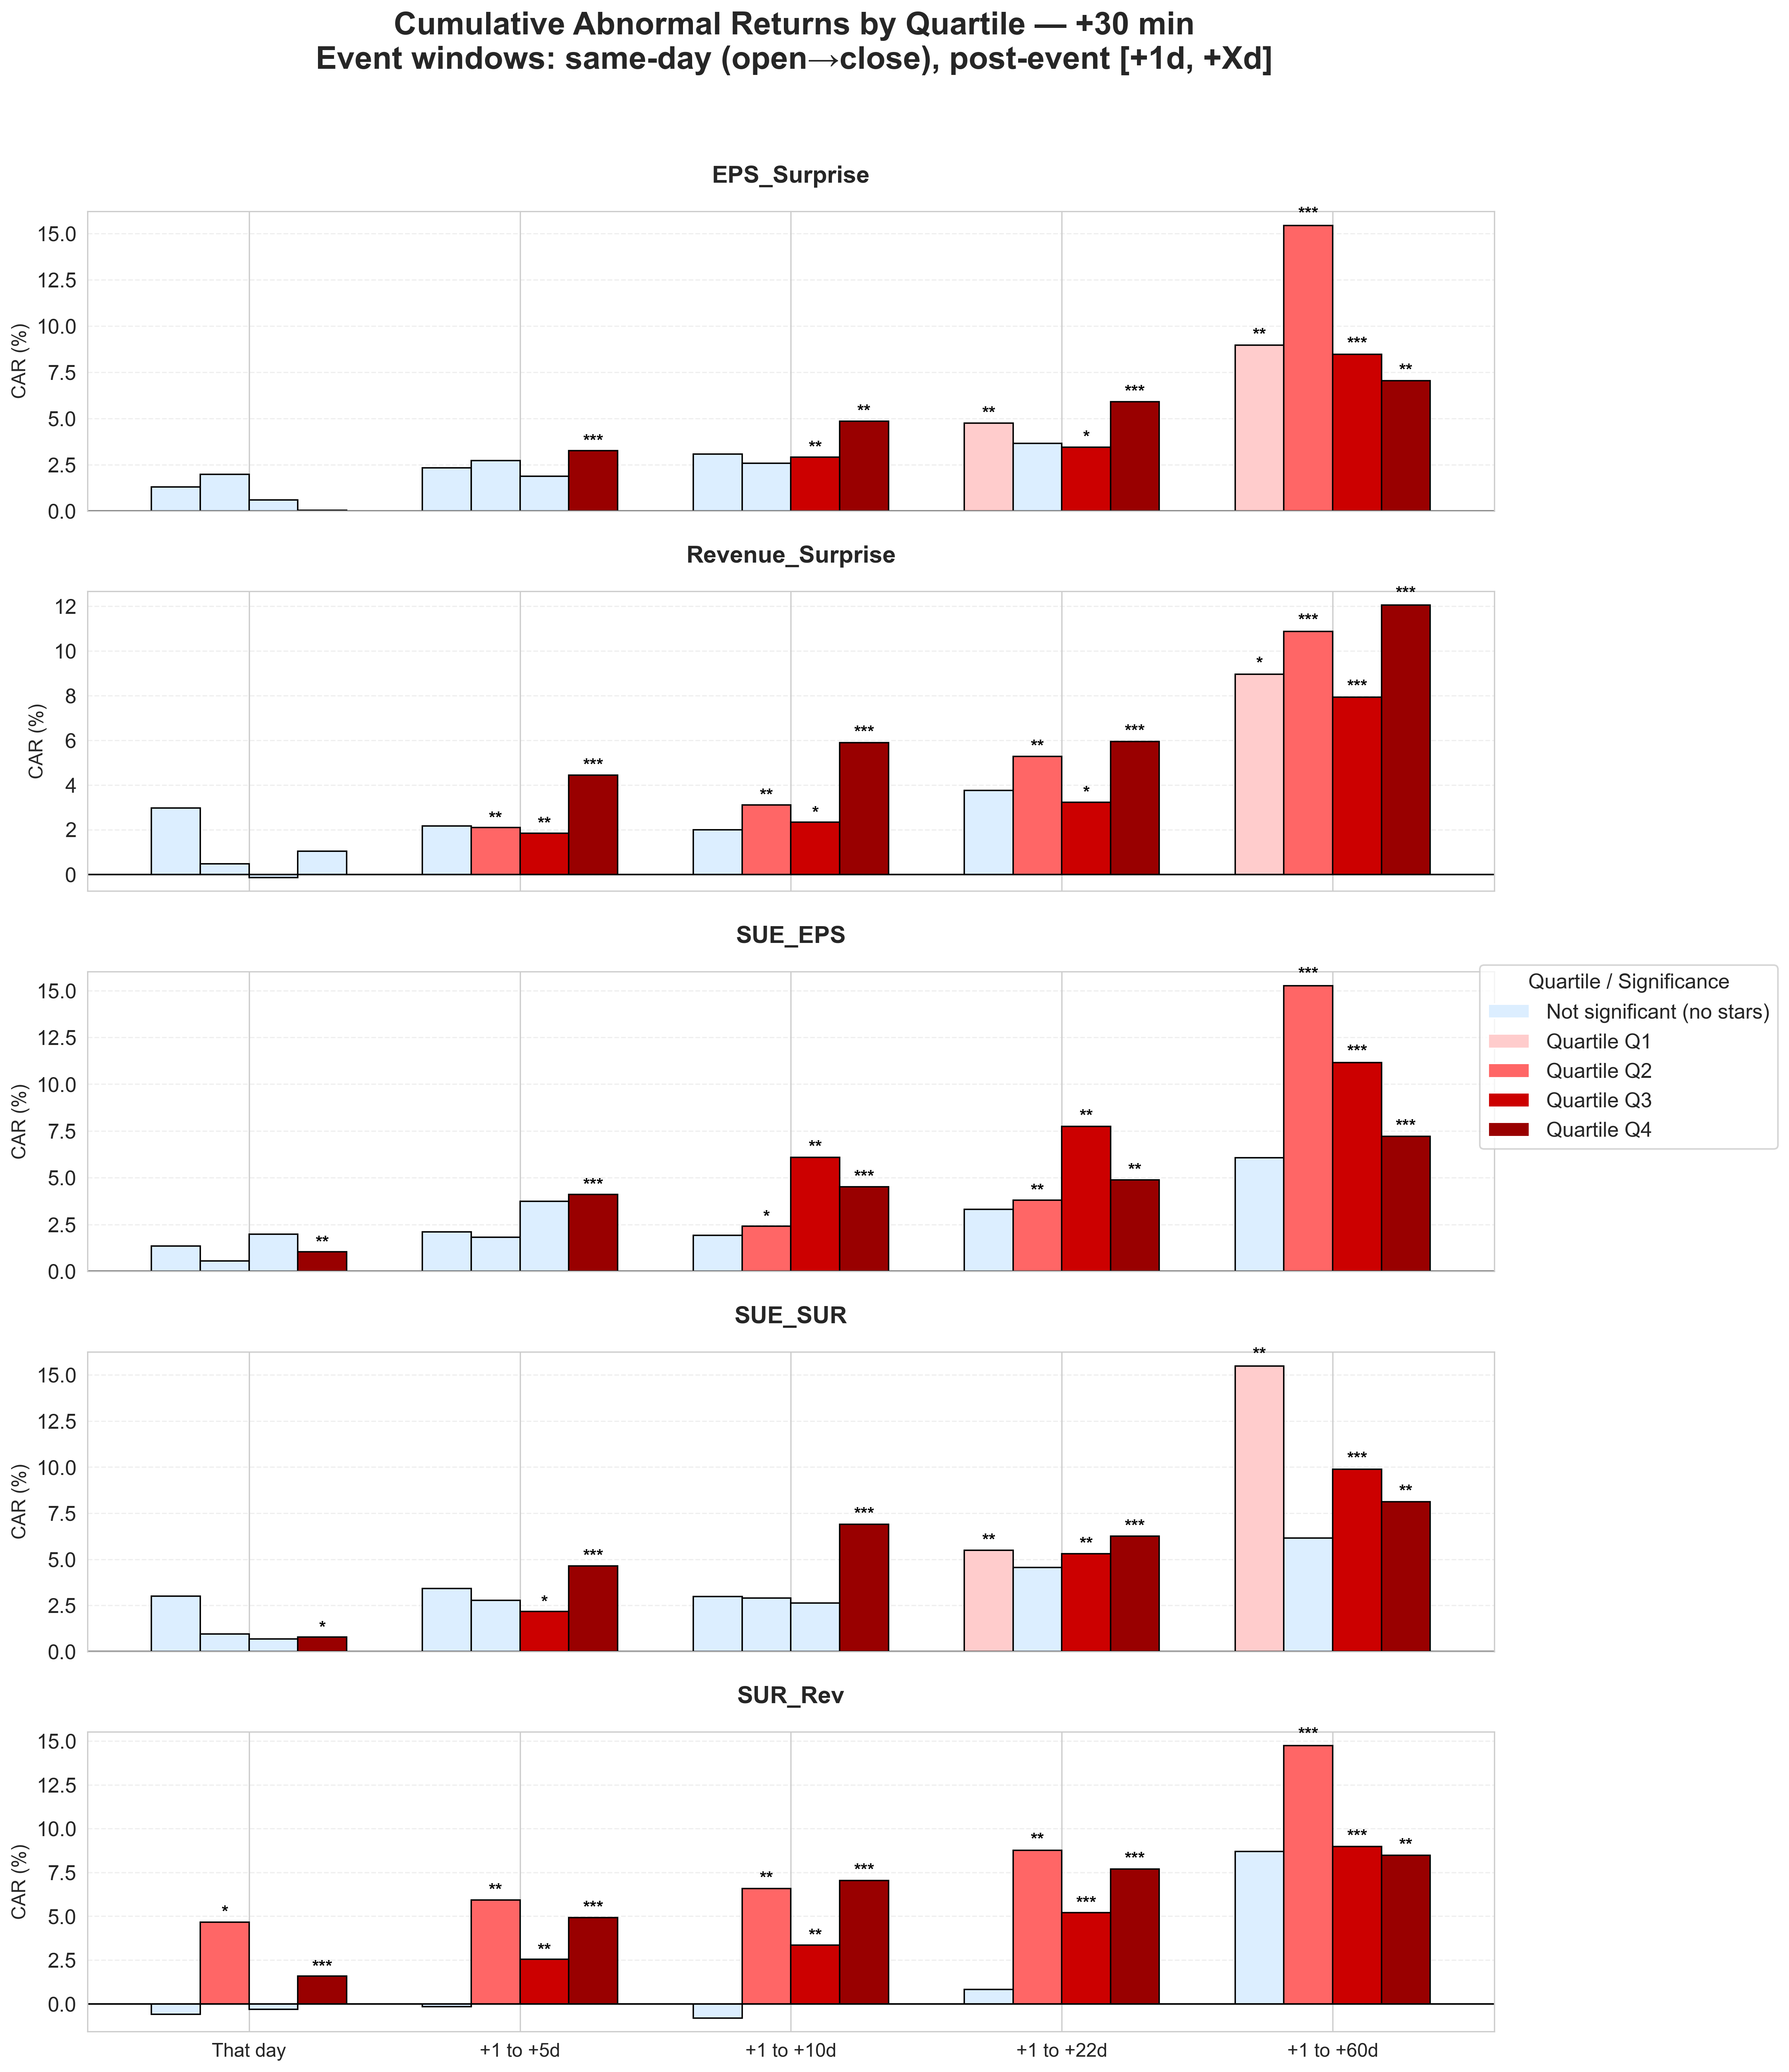


Soubor: CAR_Quartiles_RedBlue_5min.png


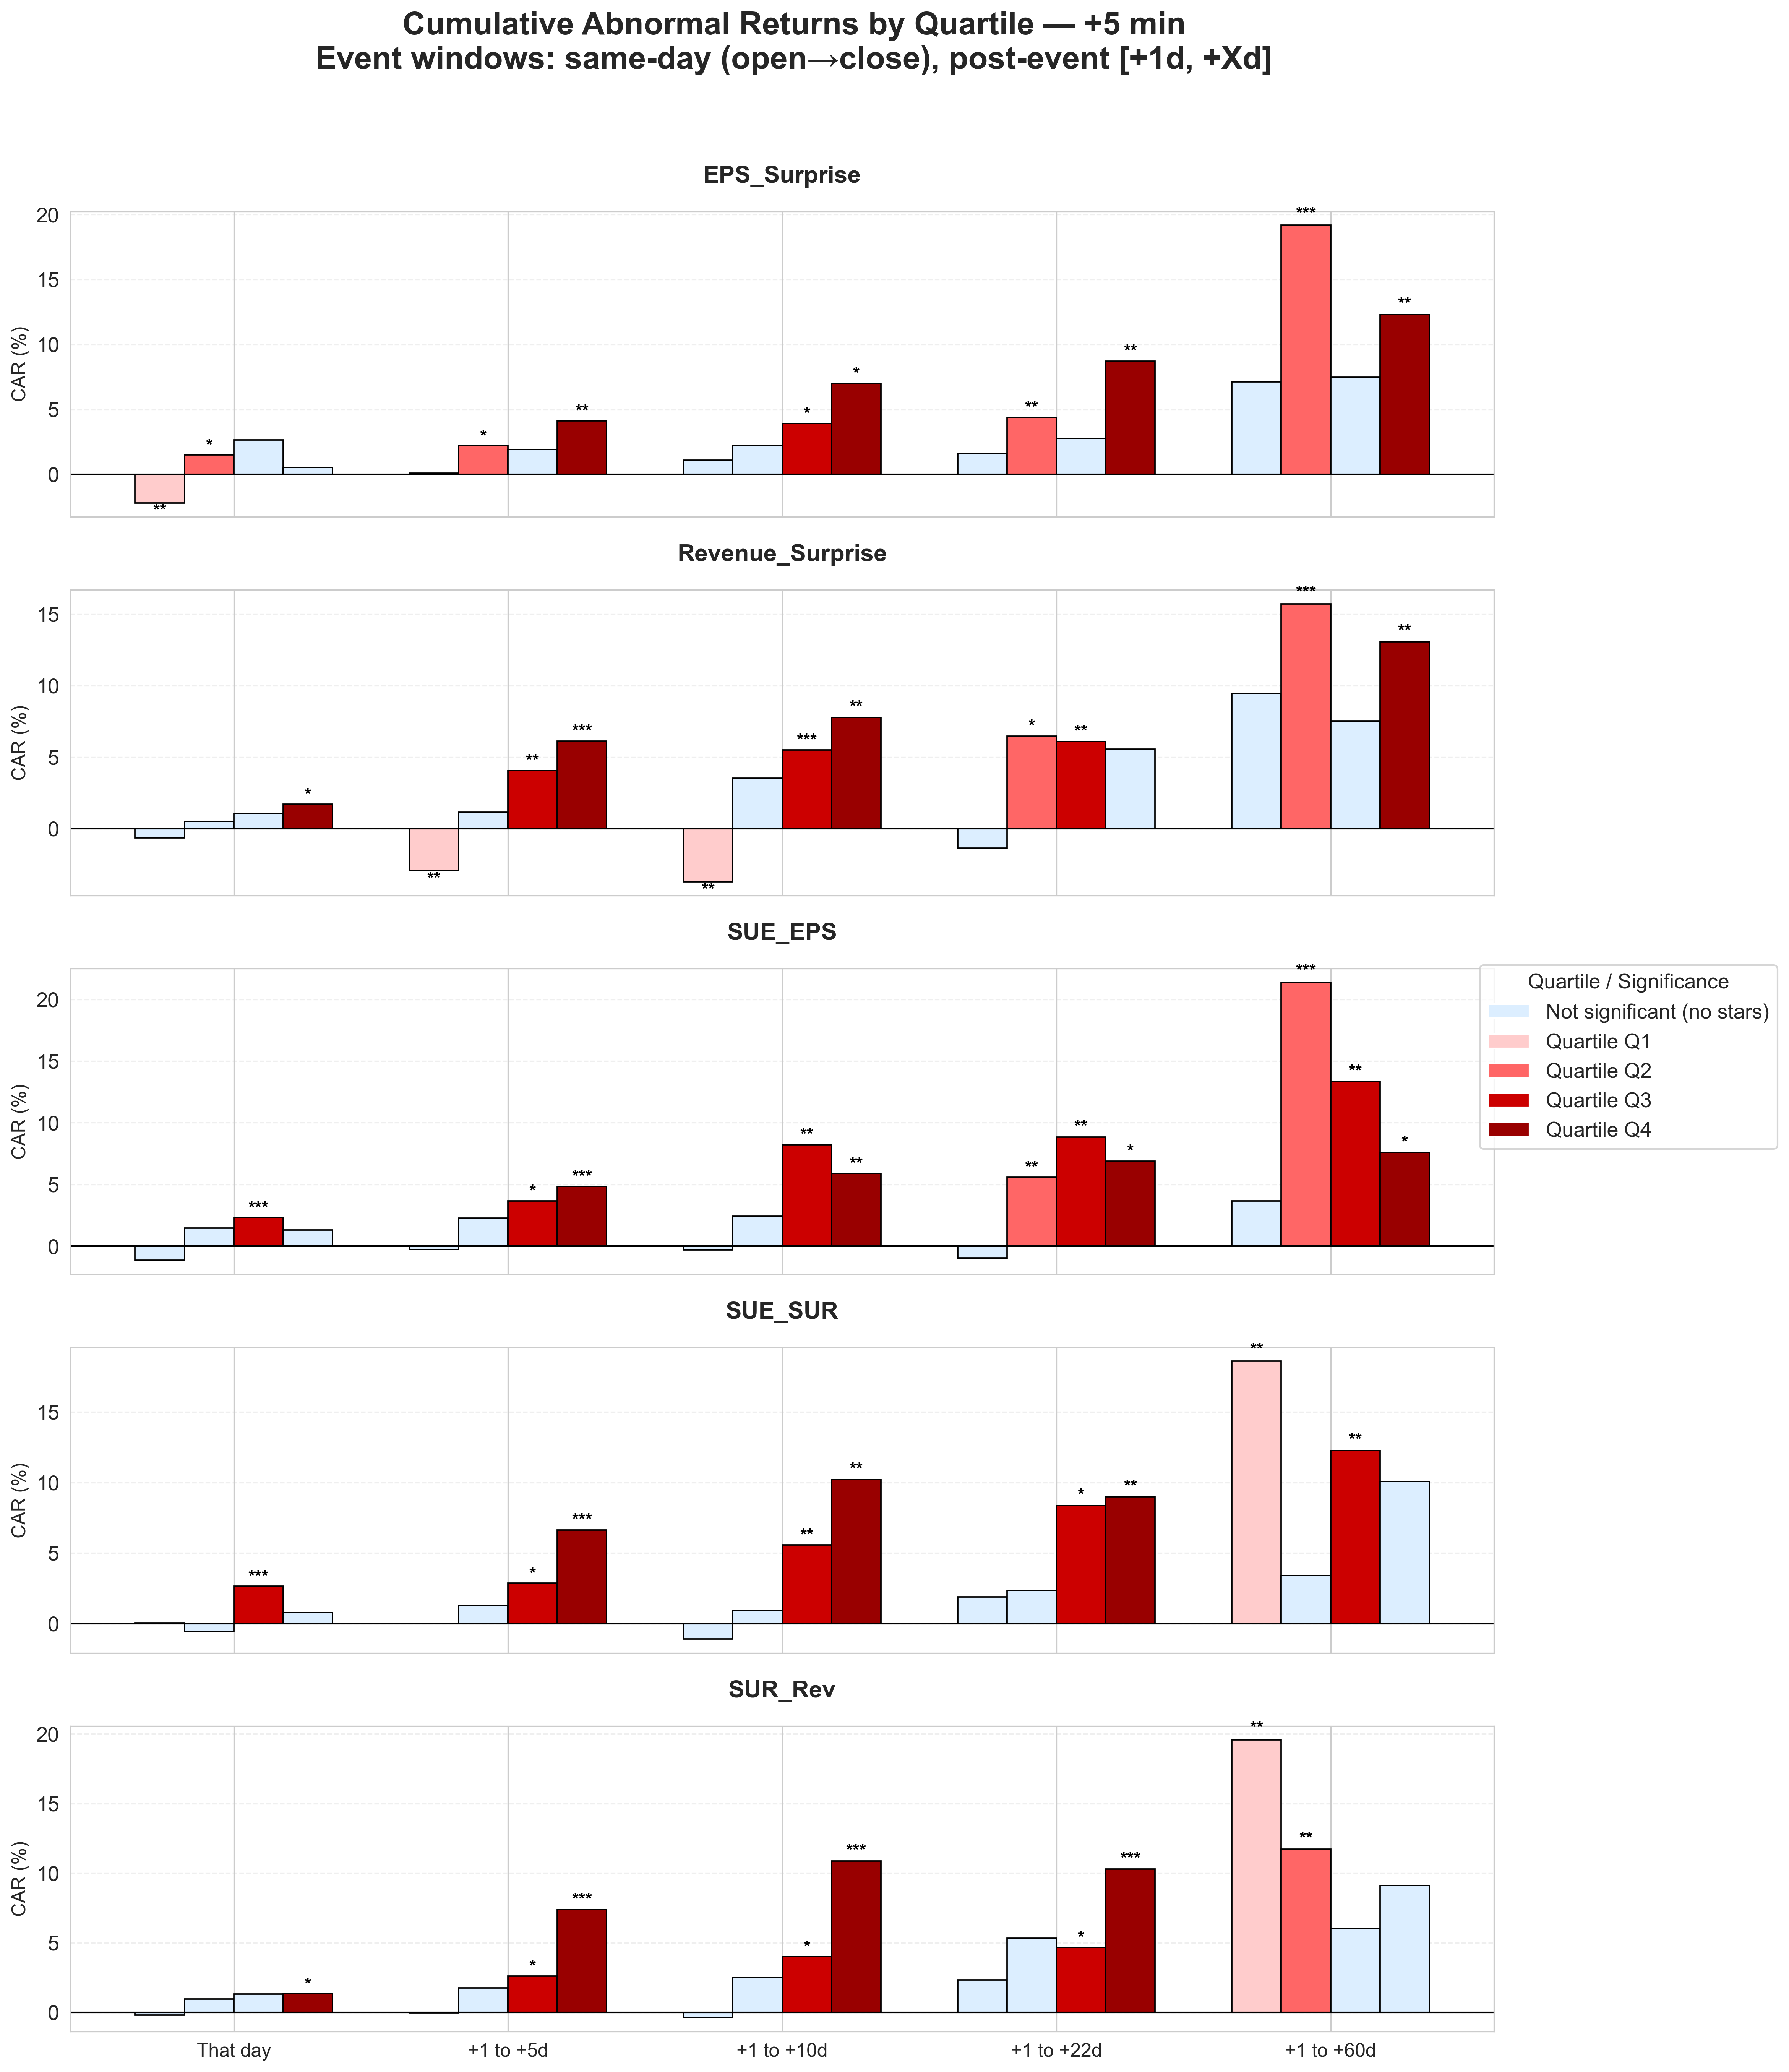

In [6]:
import glob
from IPython.display import Image, display
from pathlib import Path

# Nastavení cesty
folder = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\charts_quartiles\charts_quartiles_redblue")

# Najde všechny .png soubory bez ohledu na přesný název
images = glob.glob(str(folder / "*.png"))

if not images:
    print(f"Složka je prázdná nebo neexistuje: {folder}")
else:
    print(f"Nalezeno {len(images)} grafů. Zobrazuji:")
    for img_path in sorted(images):
        print(f"\nSoubor: {Path(img_path).name}")
        display(Image(filename=img_path))

In [ ]:
# CAR_BY_CATEGORY_MEGA_FINAL.py
# → Výpočet RAW CAR pro mega_finalX.csv
# → Priorita kategorií: Podle hierarchického pořadí (citováno Groß-Klußmann & Hautsch 2011, Hirschey et al. 2024)
# → Uložení RAW CAR do CSV (včetně výpočtu pro každý gap)
# → Pro multiple news: přiřadí k dominantní kategorii (nejvíce zpráv), při rovnosti přidá obě (pokud jsou v hierarchii vedle sebe nebo ob jedno)

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import time
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")

# ---------------- CONFIG ----------------
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka")
INTRADAY = BASE / "gap_trades"
MAIN_DF = BASE / "MAIN_DATAFRAME"

MEGA_FILES = {
    "plus1": MAIN_DF / "news_final" / "mega_final1.csv",
    "plus5": MAIN_DF / "news_final" / "mega_final5.csv",
    "plus30": MAIN_DF / "news_final" / "mega_final30.csv"
}

OUT_DIR = MAIN_DF / "car_raw"
OUT_DIR.mkdir(exist_ok=True)

ENTRY_IDX = {"plus1": 1, "plus5": 6, "plus30": 31}

WINDOWS = {
    "CAR_0d": 0,
    "CAR_5d": 5,
    "CAR_10d": 10,
    "CAR_22d": 22,
    "CAR_60d": 60
}

# Hierarchické pořadí kategorií (citováno Groß-Klußmann & Hautsch 2011, Hirschey et al. 2024)
HIERARCHY_ORDER = [
    "news_Guidance___Outlook_count",      # 1
    "news_M&A___Deal_count",              # 2
    "news_Product_News_count",            # 3
    "news_Regulatory_Approval_count",     # 4
    "news_Analyst___Rating_count",        # 5
    "news_Financing___Capital_count",     # 6
    "news_Management___Legal_count",      # 7
    "news_Dividends___Buybacks_count"     # 8
]

# ---------------- HELPERY ----------------
def build_daily_lookup(daily_df):
    daily_lookup = {}
    daily_grouped_dates = {}
    for sym, g in daily_df.groupby("symbol"):
        g_sorted = g.sort_values("Date")
        arr = g_sorted["Date"].values
        daily_grouped_dates[sym] = arr
        for d, price in zip(g_sorted["Date"], g_sorted["close_price"]):
            daily_lookup[(sym, d)] = float(price)
    return daily_lookup, daily_grouped_dates

_intraday_cache = {}
def load_intraday_cached(path):
    if path in _intraday_cache:
        return _intraday_cache[path]
    try:
        df = pd.read_csv(path, parse_dates=["Datetime"], low_memory=False)
    except Exception:
        _intraday_cache[path] = None
        return None
    if "Datetime" not in df.columns or "Open" not in df.columns:
        _intraday_cache[path] = None
        return None
    df = df[["Datetime","Open"]].dropna().sort_values("Datetime").reset_index(drop=True)
    df = df[df["Datetime"].dt.time >= time(9,30)].reset_index(drop=True)
    _intraday_cache[path] = df
    return df

intraday_letter_folder_cache = {p.name.split("_")[1].upper():p for p in INTRADAY.iterdir() if p.is_dir() and p.name.lower().startswith("stock_")}
_symbol_file_cache = {}
def get_intraday_path_for(sym, date_dt):
    key = (sym, date_dt.strftime("%Y-%m-%d"))
    if key in _symbol_file_cache:
        return _symbol_file_cache[key]
    folder = intraday_letter_folder_cache.get(sym[0].upper())
    if folder is None:
        _symbol_file_cache[key] = None
        return None
    fname = f"{sym}_{date_dt.strftime('%Y-%m-%d')}.csv"
    p = folder / fname
    if p.exists():
        _symbol_file_cache[key] = p
        return p
    matches = list(folder.glob(f"{sym}_{date_dt.strftime('%Y-%m-%d')}*.csv"))
    _symbol_file_cache[key] = matches[0] if matches else None
    return _symbol_file_cache[key]

def find_trading_index(dates_arr, target_date_ts):
    if dates_arr is None or len(dates_arr)==0:
        return None
    t64 = np.datetime64(pd.to_datetime(target_date_ts))
    idx = np.searchsorted(dates_arr, t64)
    if idx < len(dates_arr) and dates_arr[idx]==t64:
        return int(idx)
    if idx-1>=0 and dates_arr[idx-1]==t64:
        return int(idx-1)
    return None

# ---------------- LOAD DAILY ----------------
daily_raw = pd.read_csv(MAIN_DF / "MAIN_DF_final.csv", low_memory=False)
daily_raw["Date"] = pd.to_datetime(daily_raw["Date"], errors="coerce")
daily_raw = daily_raw.dropna(subset=["Date"])
daily_raw["symbol"] = daily_raw["Ticker"].astype(str).str.upper()
daily_raw["close_price"] = daily_raw["Close"].astype(float)
daily = daily_raw[["symbol","Date","close_price"]].sort_values(["symbol","Date"]).reset_index(drop=True)
daily_lookup, daily_grouped = build_daily_lookup(daily)

# ---------------- HIERARCHICKÁ PRIORITA ----------------
def pick_category(row):
    counts = {cat: row.get(cat, 0) for cat in HIERARCHY_ORDER}
    max_count = max(counts.values())
    if max_count == 0:
        return ["No_news"]
    
    # Najdi kategorie s max počtem zpráv
    top_cats = [cat for cat, v in counts.items() if v == max_count]
    
    # Pokud jen jedna – vrátit ji
    if len(top_cats) == 1:
        return [top_cats[0]]
    
    # Pokud více – zjistit pozice v hierarchii
    positions = {cat: HIERARCHY_ORDER.index(cat) for cat in top_cats}
    
    # Sort podle pozice (nižší index = vyšší priorita)
    sorted_tops = sorted(top_cats, key=lambda c: positions[c])
    
    # Tie-break: pokud jsou vedle sebe nebo ob jedno (|pos diff| <=2), přiřadit obě
    selected = [sorted_tops[0]]
    for i in range(1, len(sorted_tops)):
        prev_pos = positions[sorted_tops[i-1]]
        curr_pos = positions[sorted_tops[i]]
        if abs(curr_pos - prev_pos) <= 2:
            selected.append(sorted_tops[i])
        else:
            break  # Pokud nejsou blízko, vzít jen nejvyšší prioritu
    
    return selected  # Vrátí list kategorií (1 nebo 2)

# ---------------- PROCESS MEGA ----------------
for key, path in MEGA_FILES.items():
    print(f"\n{'='*80}")
    print(f"ZPRACOVÁVÁM: {key} ({path.name})")
    print(f"{'='*80}")

    df = pd.read_csv(path, low_memory=False)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df[df["Date"].dt.year.between(2016, 2023)].copy()
    df["symbol"] = df["symbol"].str.upper()
    df["gap_key"] = df["symbol"] + "_" + df["Date"].dt.strftime("%Y-%m-%d")

    # Výpočet CAR
    df_cars = []
    for _, row in df.iterrows():
        sym = row["symbol"]
        edate = row["Date"]
        
        pth = get_intraday_path_for(sym, edate)
        if pth is None:
            continue
        idf = load_intraday_cached(pth)
        if idf is None or len(idf) <= ENTRY_IDX[key]:
            continue
        entry_price = idf.iloc[ENTRY_IDX[key]]["Open"]
        if pd.isna(entry_price) or entry_price <= 0:
            continue
        
        dates_arr = daily_grouped.get(sym)
        if dates_arr is None:
            continue
        pos = find_trading_index(dates_arr, edate)
        if pos is None:
            continue
        
        # Získej list kategorií (1 nebo 2)
        categories = pick_category(row)
        
        # Pro každou kategorii přidej řádek
        for cat in categories:
            car_row = {
                "gap_key": row["gap_key"],
                "symbol": sym,
                "Date": edate,
                "main_category": cat
            }
            
            for wname, offset in WINDOWS.items():
                exit_pos = pos + offset
                if exit_pos >= len(dates_arr):
                    car_row[wname] = np.nan
                    continue
                exit_date = pd.to_datetime(dates_arr[exit_pos])
                exit_price = daily_lookup.get((sym, exit_date))
                if exit_price is None or exit_price <= 0:
                    car_row[wname] = np.nan
                    continue
                car_row[wname] = (exit_price / entry_price) - 1
            
            df_cars.append(car_row)
    
    out_df = pd.DataFrame(df_cars)
    out_file = OUT_DIR / f"CAR_RAW_{key}.csv"
    out_df.to_csv(out_file, index=False, encoding="utf-8-sig")
    print(f"ULOŽENO: {out_file} ({len(out_df)} řádků)")

In [1]:
# Každý gap dostane jen jednu kategorii podle hierarchie
# ================================================================

import pandas as pd
import numpy as np
from pathlib import Path
from datetime import time
import warnings
warnings.filterwarnings("ignore")

# ---------------- CONFIG ----------------
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka")
INTRADAY = BASE / "gap_trades"
MAIN_DF = BASE / "MAIN_DATAFRAME"

MEGA_FILES = {
    "plus1": MAIN_DF / "news_final" / "mega_final1.csv",
    "plus5": MAIN_DF / "news_final" / "mega_final5.csv",
    "plus30": MAIN_DF / "news_final" / "mega_final30.csv"
}

OUT_DIR = MAIN_DF / "car_raw"
OUT_DIR.mkdir(exist_ok=True)

ENTRY_IDX = {"plus1": 1, "plus5": 6, "plus30": 31}

WINDOWS = {
    "CAR_0d": 0,
    "CAR_5d": 5,
    "CAR_10d": 10,
    "CAR_22d": 22,
    "CAR_60d": 60
}

# Strict hierarchical order (Groß-Klußmann & Hautsch 2011, Hirschey et al. 2024)
HIERARCHY_ORDER = [
    "news_Guidance___Outlook_count",      # 1
    "news_M&A___Deal_count",              # 2
    "news_Product_News_count",            # 3
    "news_Regulatory_Approval_count",     # 4
    "news_Analyst___Rating_count",        # 5
    "news_Financing___Capital_count",     # 6
    "news_Management___Legal_count",      # 7
    "news_Dividends___Buybacks_count"     # 8
]

# ---------------- HELPERS ----------------
def build_daily_lookup(daily_df):
    daily_lookup = {}
    daily_grouped_dates = {}
    for sym, g in daily_df.groupby("symbol"):
        g_sorted = g.sort_values("Date")
        arr = g_sorted["Date"].values
        daily_grouped_dates[sym] = arr
        for d, price in zip(g_sorted["Date"], g_sorted["close_price"]):
            daily_lookup[(sym, pd.to_datetime(d))] = float(price)
    return daily_lookup, daily_grouped_dates

_intraday_cache = {}
def load_intraday_cached(path):
    if path in _intraday_cache:
        return _intraday_cache[path]
    try:
        df = pd.read_csv(path, parse_dates=["Datetime"], low_memory=False)
    except Exception:
        _intraday_cache[path] = None
        return None
    if "Datetime" not in df.columns or "Open" not in df.columns:
        _intraday_cache[path] = None
        return None
    df = df[["Datetime","Open"]].dropna().sort_values("Datetime").reset_index(drop=True)
    df = df[df["Datetime"].dt.time >= time(9,30)].reset_index(drop=True)
    _intraday_cache[path] = df
    return df

intraday_letter_folder_cache = {p.name.split("_")[1].upper(): p 
                                for p in INTRADAY.iterdir() if p.is_dir() and p.name.lower().startswith("stock_")}
_symbol_file_cache = {}
def get_intraday_path_for(sym, date_dt):
    key = (sym, date_dt.strftime("%Y-%m-%d"))
    if key in _symbol_file_cache:
        return _symbol_file_cache[key]
    folder = intraday_letter_folder_cache.get(sym[0].upper())
    if folder is None:
        _symbol_file_cache[key] = None
        return None
    fname = f"{sym}_{date_dt.strftime('%Y-%m-%d')}.csv"
    p = folder / fname
    if p.exists():
        _symbol_file_cache[key] = p
        return p
    matches = list(folder.glob(f"{sym}_{date_dt.strftime('%Y-%m-%d')}*.csv"))
    _symbol_file_cache[key] = matches[0] if matches else None
    return _symbol_file_cache[key]

def find_trading_index(dates_arr, target_date_ts):
    if dates_arr is None or len(dates_arr)==0:
        return None
    t64 = np.datetime64(pd.to_datetime(target_date_ts))
    idx = np.searchsorted(dates_arr, t64)
    if idx < len(dates_arr) and dates_arr[idx]==t64:
        return int(idx)
    if idx-1 >= 0 and dates_arr[idx-1]==t64:
        return int(idx-1)
    return None

# ---------------- LOAD DAILY ----------------
daily_raw = pd.read_csv(MAIN_DF / "MAIN_DF_final.csv", low_memory=False)
daily_raw["Date"] = pd.to_datetime(daily_raw["Date"], errors="coerce")
daily_raw = daily_raw.dropna(subset=["Date"])
daily_raw["symbol"] = daily_raw["Ticker"].astype(str).str.upper()
daily_raw["close_price"] = daily_raw["Close"].astype(float)
daily = daily_raw[["symbol","Date","close_price"]].sort_values(["symbol","Date"]).reset_index(drop=True)
daily_lookup, daily_grouped = build_daily_lookup(daily)

# ---------------- STRICT HIERARCHICAL CATEGORY ----------------
def pick_category(row):
    """
    Strict hierarchy: return the highest-priority category with >0 news.
    Always returns a single string.
    """
    for cat in HIERARCHY_ORDER:
        if row.get(cat, 0) > 0:
            return cat
    return "No_news"

# ---------------- PROCESS MEGA ----------------
for key, path in MEGA_FILES.items():
    print(f"\n{'='*80}")
    print(f"ZPRACOVÁVÁM: {key} ({path.name})")
    print(f"{'='*80}")

    df = pd.read_csv(path, low_memory=False)
    df["Date"] = pd.to_datetime(df["Date"])
    df = df[df["Date"].dt.year.between(2016, 2023)].copy()
    df["symbol"] = df["symbol"].str.upper()
    df["gap_key"] = df["symbol"] + "_" + df["Date"].dt.strftime("%Y-%m-%d")

    # Compute CAR
    df_cars = []
    for _, row in df.iterrows():
        sym = row["symbol"]
        edate = row["Date"]
        
        pth = get_intraday_path_for(sym, edate)
        if pth is None:
            continue
        idf = load_intraday_cached(pth)
        if idf is None or len(idf) <= ENTRY_IDX[key]:
            continue
        entry_price = idf.iloc[ENTRY_IDX[key]]["Open"]
        if pd.isna(entry_price) or entry_price <= 0:
            continue
        
        dates_arr = daily_grouped.get(sym)
        if dates_arr is None:
            continue
        pos = find_trading_index(dates_arr, edate)
        if pos is None:
            continue
        
        category = pick_category(row)  # single category only
        
        car_row = {
            "gap_key": row["gap_key"],
            "symbol": sym,
            "Date": edate,
            "main_category": category
        }
        
        for wname, offset in WINDOWS.items():
            exit_pos = pos + offset
            if exit_pos >= len(dates_arr):
                car_row[wname] = np.nan
                continue
            exit_date = pd.to_datetime(dates_arr[exit_pos])
            exit_price = daily_lookup.get((sym, exit_date))
            if exit_price is None or exit_price <= 0:
                car_row[wname] = np.nan
                continue
            car_row[wname] = (exit_price / entry_price) - 1
        
        df_cars.append(car_row)
    
    out_df = pd.DataFrame(df_cars)
    out_file = OUT_DIR / f"CAR_RAW_new_{key}.csv"
    out_df.to_csv(out_file, index=False, encoding="utf-8-sig")
    print(f"ULOŽENO: {out_file} ({len(out_df)} řádků)")

print("\nHOTOVO – všechny RAW CAR uložené s přísnou hierarchií!")



ZPRACOVÁVÁM: plus1 (mega_final1.csv)
ULOŽENO: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\car_raw\CAR_RAW_new_plus1.csv (6796 řádků)

ZPRACOVÁVÁM: plus5 (mega_final5.csv)
ULOŽENO: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\car_raw\CAR_RAW_new_plus5.csv (8767 řádků)

ZPRACOVÁVÁM: plus30 (mega_final30.csv)
ULOŽENO: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\car_raw\CAR_RAW_new_plus30.csv (9769 řádků)

HOTOVO – všechny RAW CAR uložené s přísnou hierarchií!


In [4]:
import pandas as pd
import numpy as np
from scipy import stats
from pathlib import Path

# Cesta k souborům
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\car_raw")

# Soubory pro všechny filtry
FILES = {
    "+1 min": BASE / "CAR_RAW_new_plus1.csv",
    "+5 min": BASE / "CAR_RAW_new_plus5.csv",
    "+30 min": BASE / "CAR_RAW_new_plus30.csv"
}

# CAR sloupce
CAR_COLS = ["CAR_0d", "CAR_5d", "CAR_10d", "CAR_22d", "CAR_60d"]

# Mapování hezkých názvů kategorií (volitelné, ale doporučuji)
CATEGORY_LABELS = {
    "No_news": "No news",
    "news_Guidance___Outlook_count": "Guidance",
    "news_M&A___Deal_count": "M&A/Deal",
    "news_Product_News_count": "Product",
    "news_Regulatory_Approval_count": "Regulatory Approval",
    "news_Analyst___Rating_count": "Analyst Rating",
    "news_Management___Legal_count": "Management/Legal",
    "news_Dividends___Buybacks_count": "Dividends/Buybacks",
    "news_Financing___Capital_count": "Financing/Capital"
}

# Pro všechny filtry
for label, file_path in FILES.items():
    print(f"\n{'='*80}")
    print(f"TABULKA CAR PRO FILTR: {label}")
    print(f"{'='*80}")
    
    if not file_path.exists():
        print(f"SOUBOR NEEXISTUJE: {file_path}")
        continue
    
    # Načti data
    df = pd.read_csv(file_path, parse_dates=["Date"])
    
    # Výpočet průměrů a t-testů
    results = []
    for cat, g in df.groupby("main_category"):
        row = {"Category": CATEGORY_LABELS.get(cat, cat)}  # Hezký název
        row["N"] = len(g)  # Počet událostí
        for col in CAR_COLS:
            vals = g[col].dropna()
            if len(vals) >= 2:
                mean = np.mean(vals) * 100  # Na procenta
                t_stat, p_val = stats.ttest_1samp(vals, 0)
                stars = "***" if p_val < 0.01 else "**" if p_val < 0.05 else "*" if p_val < 0.1 else ""
                row[col] = f"{mean:.2f}{stars}"
            else:
                row[col] = "-"
        results.append(row)
    
    # Vytvoř tabulku a vytiskni
    table_df = pd.DataFrame(results)
    # Seřaď podle pořadí kategorií (volitelně)
    order = ["No news", "Guidance", "M&A/Deal", "Product", "Regulatory Approval",
             "Analyst Rating", "Financing/Capital", "Management/Legal", "Dividends/Buybacks"]
    table_df["Category"] = pd.Categorical(table_df["Category"], categories=order, ordered=True)
    table_df = table_df.sort_values("Category").reset_index(drop=True)
    
    print(table_df.to_string(index=False))
    
    # Volitelně ulož do CSV
    out_file = BASE / f"CAR_table_{label.replace(' ', '_').replace('+', '')}.csv"
    table_df.to_csv(out_file, index=False, encoding="utf-8-sig")
    print(f"\n→ Tabulka uložena: {out_file}")


TABULKA CAR PRO FILTR: +1 min
           Category    N   CAR_0d    CAR_5d   CAR_10d   CAR_22d   CAR_60d
            No news 5486    -0.66  -6.18***  -6.24***  -5.96***   -6.19**
           Guidance  141  -4.07**  -6.29***   -6.42**     -2.54      6.62
           M&A/Deal  524   -3.57*  -9.53*** -11.20*** -13.40***   -9.31**
            Product  338   -5.52* -12.42*** -12.58*** -12.69***    -9.64*
Regulatory Approval  182  -4.47**  -7.67***   -6.34**     -7.28     -6.26
     Analyst Rating   48    -0.56     -1.73     -3.45    -9.22* -22.80***
  Financing/Capital   51    -2.70     -3.11    -8.56*     -6.43  -13.37**
   Management/Legal   15 -14.88**    -13.41     -3.98      6.77     18.98
 Dividends/Buybacks   11    12.91      6.78     -4.05     -4.26      1.26

→ Tabulka uložena: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\car_raw\CAR_table_1_min.csv

TABULKA CAR PRO FILTR: +5 min
           Category    N   CAR_0d   CAR_5d   CAR_10d   CAR_22d  CAR_60d
            No news 7018   


Loading 1min: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\car_raw\CAR_RAW_new_plus1.csv


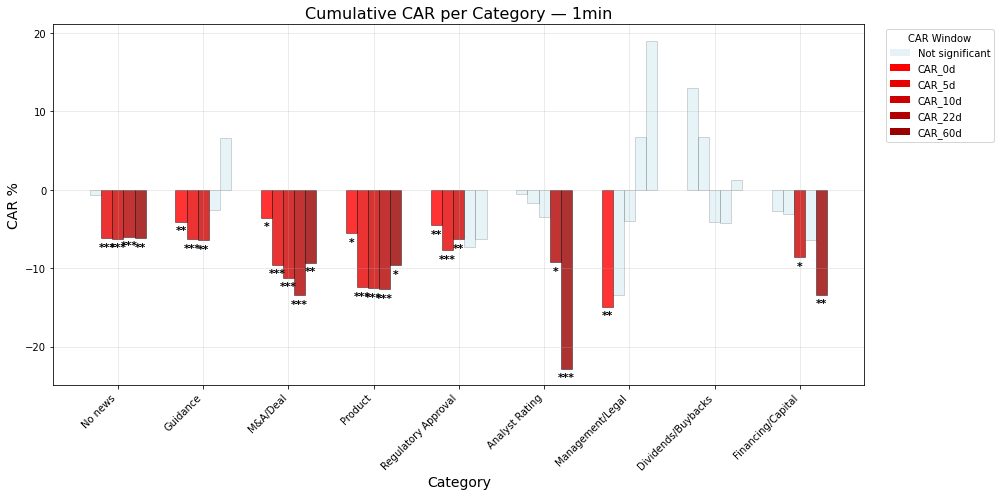


Loading 5min: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\car_raw\CAR_RAW_new_plus5.csv


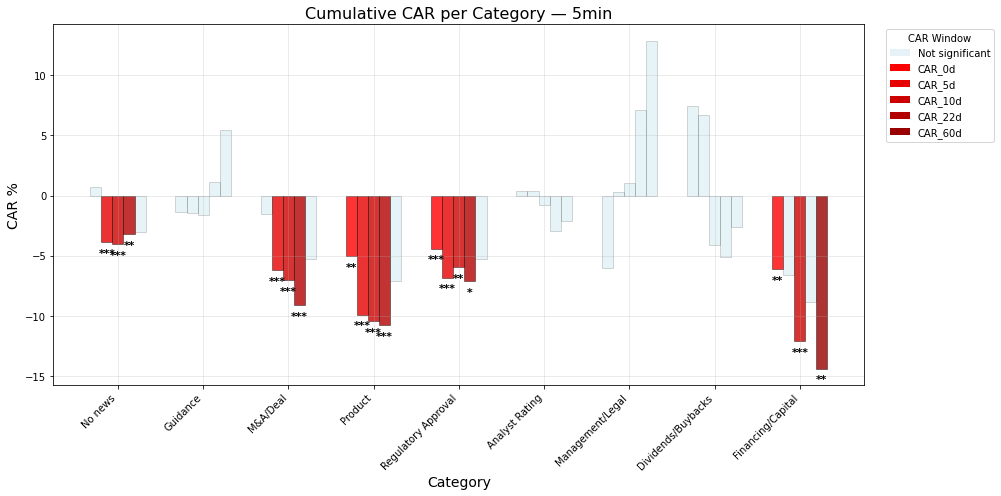


Loading 30min: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\car_raw\CAR_RAW_new_plus30.csv


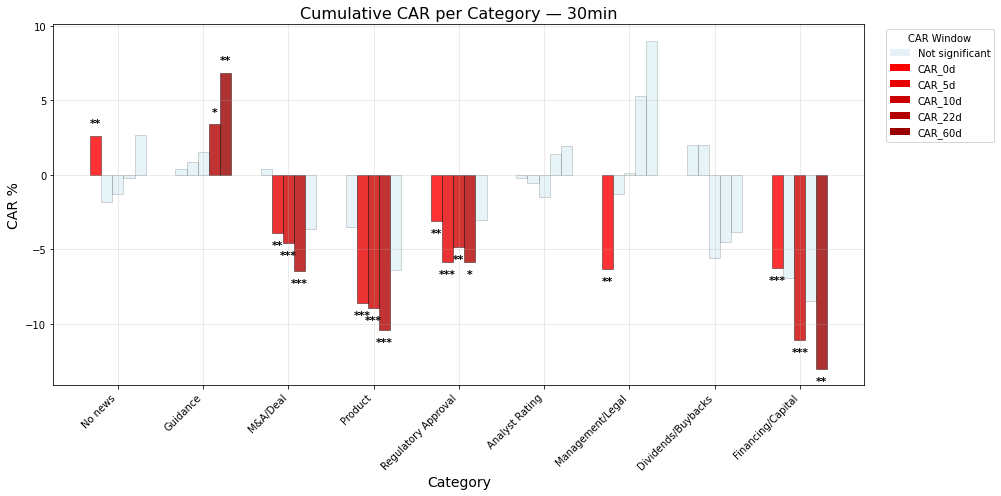

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats
import numpy as np
from matplotlib.patches import Patch

# ------------------------------------------------
# CONFIG
# ------------------------------------------------
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\car_raw")

FILES = {
    "1min": BASE / "CAR_RAW_new_plus1.csv",
    "5min": BASE / "CAR_RAW_new_plus5.csv",
    "30min": BASE / "CAR_RAW_new_plus30.csv"
}

CAR_COLS = ["CAR_0d", "CAR_5d", "CAR_10d", "CAR_22d", "CAR_60d"]

RAW_CATEGORIES = [
    "No_news",
    "news_Guidance___Outlook_count",
    "news_M&A___Deal_count",
    "news_Product_News_count",
    "news_Regulatory_Approval_count",
    "news_Analyst___Rating_count",
    "news_Management___Legal_count",
    "news_Dividends___Buybacks_count",
    "news_Financing___Capital_count"
]

CATEGORY_LABELS = {
    "No_news": "No news",
    "news_Guidance___Outlook_count": "Guidance",
    "news_M&A___Deal_count": "M&A/Deal",
    "news_Product_News_count": "Product",
    "news_Regulatory_Approval_count": "Regulatory Approval",
    "news_Analyst___Rating_count": "Analyst Rating",
    "news_Management___Legal_count": "Management/Legal",
    "news_Dividends___Buybacks_count": "Dividends/Buybacks",
    "news_Financing___Capital_count": "Financing/Capital"
}

# Shades of red for each CAR window
RED_SHADES = {
    "CAR_0d": "#FF0000",
    "CAR_5d": "#E60000",
    "CAR_10d": "#CC0000",
    "CAR_22d": "#B30000",
    "CAR_60d": "#990000"
}

# ------------------------------------------------
# SIGNIFICANCE STARS
# ------------------------------------------------
def stars_from_p(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

# ------------------------------------------------
# PROCESS + PLOT
# ------------------------------------------------
for label, fpath in FILES.items():
    print(f"\nLoading {label}: {fpath}")

    df = pd.read_csv(fpath, parse_dates=["Date"])
    df = df[df["main_category"].isin(RAW_CATEGORIES)]

    # Mean CARs
    mean_car = df.groupby("main_category")[CAR_COLS].mean().reindex(RAW_CATEGORIES)

    # p-values
    p_values = pd.DataFrame(index=RAW_CATEGORIES, columns=CAR_COLS, dtype=float)

    for cat in RAW_CATEGORIES:
        sub = df[df["main_category"] == cat]
        for col in CAR_COLS:
            vals = sub[col].dropna()
            if len(vals) >= 2:
                _, p_val = stats.ttest_1samp(vals, 0)
                p_values.loc[cat, col] = p_val

    # Pretty labels
    mean_car.index = [CATEGORY_LABELS[x] for x in mean_car.index]
    p_values.index = [CATEGORY_LABELS[x] for x in p_values.index]

    # ---------------- PLOT ----------------
    plt.figure(figsize=(14, 7))
    bar_width = 0.13
    x = np.arange(len(mean_car))

    for i, car_col in enumerate(CAR_COLS):
        for j, cat in enumerate(mean_car.index):

            value = mean_car.loc[cat, car_col] * 100  # CAR %
            p_val = p_values.loc[cat, car_col]
            stars = stars_from_p(p_val)

            significant = stars != ""
            color = RED_SHADES[car_col] if significant else "lightblue"
            alpha = 0.8 if significant else 0.3

            xpos = x[j] + i * bar_width

            plt.bar(
                xpos,
                value,
                width=bar_width,
                color=color,
                alpha=alpha,
                edgecolor="black",
                linewidth=0.5
            )

            # ---- ADD STARS ----
            if stars:
                offset = 0.5
                y = value + offset if value >= 0 else value - offset
                plt.text(
                    xpos,
                    y,
                    stars,
                    ha="center",
                    va="bottom" if value >= 0 else "top",
                    fontsize=11,
                    fontweight="bold"
                )

    plt.title(f"Cumulative CAR per Category — {label}", fontsize=16)
    plt.ylabel("CAR %", fontsize=14)
    plt.xlabel("Category", fontsize=14)
    plt.xticks(x + bar_width * 2, mean_car.index, rotation=45, ha="right")

    legend_elements = (
        [Patch(facecolor="lightblue", alpha=0.3, label="Not significant")] +
        [Patch(facecolor=RED_SHADES[c], label=f"{c}") for c in CAR_COLS]
    )

    plt.legend(
        handles=legend_elements,
        title="CAR Window",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(BASE / f"CAR_Category_{label}.png", dpi=300, bbox_inches="tight")
    plt.savefig(BASE / f"CAR_Category_{label}.pdf", bbox_inches="tight")
    plt.show()


In [82]:
# ================================================================
# DESCRIPTIVE N PER CATEGORY (MATCHING TRUE CATEGORY CAR CHARTS)
# ================================================================

import pandas as pd
from pathlib import Path

N_OUT_DIR = BASE / "descriptive_stats"
N_OUT_DIR.mkdir(exist_ok=True)

print("\n================ SAMPLE SIZE (N) PER CATEGORY ================\n")

for label, fpath in FILES.items():
    print(f"\nProcessing {label}: {fpath}")

    df = pd.read_csv(fpath, parse_dates=["Date"])
    df = df[df["main_category"].isin(RAW_CATEGORIES)]

    # --- Total N per category ---
    n_total = (
        df.groupby("main_category")
          .size()
          .reindex(RAW_CATEGORIES)
          .rename("N_total")
    )

    # --- N per CAR window (non-missing) ---
    n_per_window = (
        df.groupby("main_category")[CAR_COLS]
          .count()
          .reindex(RAW_CATEGORIES)
    )

    # Combine
    n_df = pd.concat([n_total, n_per_window], axis=1).reset_index()
    n_df["Category"] = n_df["main_category"].map(CATEGORY_LABELS)
    n_df = n_df.drop(columns="main_category")

    # Reorder columns
    n_df = n_df[
        ["Category", "N_total", "CAR_0d", "CAR_5d", "CAR_10d", "CAR_22d", "CAR_60d"]
    ]

    # Save
    out_file = N_OUT_DIR / f"N_per_category_{label}.csv"
    n_df.to_csv(out_file, index=False, encoding="utf-8-sig")

    print(f"\nSample sizes saved to: {out_file}\n")
    print(n_df.to_string(index=False))



================ SAMPLE SIZE (N) PER CATEGORY ================


Processing 1min: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\car_raw\CAR_RAW_new_plus1.csv

Sample sizes saved to: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\gap_percent_analysis_by_category_strict\descriptive_stats\N_per_category_1min.csv

           Category  N_total  CAR_0d  CAR_5d  CAR_10d  CAR_22d  CAR_60d
            No news     5486    5486    5478     5473     5450     5387
           Guidance      141     141     141      141      141      140
           M&A/Deal      524     524     524      524      524      523
            Product      338     338     338      338      338      338
Regulatory Approval      182     182     182      182      182      182
     Analyst Rating       48      48      48       48       48       48
   Management/Legal       15      15      15       15       15       15
 Dividends/Buybacks       11      11      11       11       11       11
  Financing/Capital       51  

In [10]:
from scipy import stats
import pandas as pd

car_cols = ["CAR_0d","CAR_5d","CAR_10d","CAR_22d","CAR_60d"]

categories = df["main_category"].unique()
results = []

for cat in categories:
    cat_df = df[df["main_category"] == cat]
    N = len(cat_df)
    row = {"Category": cat, "N": N}
    for col in car_cols:
        mean_val = cat_df[col].mean()
        std_val = cat_df[col].std()
        if N > 1:
            t_stat, p_val = stats.ttest_1samp(cat_df[col], 0)
        else:
            t_stat, p_val = (float('nan'), float('nan'))  # cannot t-test with N=1
        row.update({
            f"{col}_mean": mean_val,
            f"{col}_std": std_val,
            f"{col}_t": t_stat,
            f"{col}_p": p_val
        })
    results.append(row)

panel_df = pd.DataFrame(results)
panel_df = panel_df.sort_values("Category").reset_index(drop=True)
print(panel_df)


                          Category      N  CAR_0d_mean  CAR_0d_std  CAR_0d_t  \
0                          No_news  13910     0.132692    4.884862  3.203727   
1      news_Analyst___Rating_count    220     0.030169    0.188203  2.377614   
2  news_Dividends___Buybacks_count     25     0.116465    0.351912  1.654751   
3   news_Financing___Capital_count     85    -0.013884    0.246710 -0.518846   
4    news_Guidance___Outlook_count    274     0.018620    0.235536  1.308548   
5            news_M&A___Deal_count    741     0.008509    0.422669  0.548030   
6    news_Management___Legal_count     56     0.000112    0.213240  0.003947   
7          news_Product_News_count    603    -0.028241    0.527094 -1.315691   
8   news_Regulatory_Approval_count    379    -0.026686    0.286934 -1.810619   

   CAR_0d_p  CAR_5d_mean  CAR_5d_std  CAR_5d_t  CAR_5d_p  ...  CAR_10d_t  \
0  0.001360     0.083303    3.900535       NaN       NaN  ...        NaN   
1  0.018285     0.028117    0.252516  1.651545 

In [26]:
# ================================================================
# 1_VOLUME_ANALYSIS_BY_CATEGORY_CORRECT_HIERARCHY.py
# → Strict hierarchical category assignment for volume analysis
# → Průměrný premarket a full-day volume na gap
# ================================================================

import pandas as pd
from pathlib import Path

# ---------------- CONFIG ----------------
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME")
CAR_DIR = BASE / "car_raw"
MAIN_DF = BASE / "MAIN_DF_corrected.csv"
OUT_DIR = BASE / "volume_analysis_by_category"
OUT_DIR.mkdir(exist_ok=True)

# ---------------- HIERARCHY ----------------
HIERARCHY_ORDER = [
    "news_Guidance___Outlook_count",
    "news_M&A___Deal_count",
    "news_Product_News_count",
    "news_Regulatory_Approval_count",
    "news_Analyst___Rating_count",
    "news_Financing___Capital_count",
    "news_Management___Legal_count",
    "news_Dividends___Buybacks_count"
]

# ---------------- LOAD MAIN ----------------
main = pd.read_csv(MAIN_DF, low_memory=False)
main["Date"] = pd.to_datetime(main["Date"])
main["Ticker"] = main["Ticker"].str.upper()
main = main[["Ticker", "Date", "Premarket5_USD_Volume", "USD_Volume"]].copy()
main = main.rename(columns={"Ticker": "symbol", "USD_Volume": "full_day_usd_volume"})

# ---------------- FUNCTION: PICK STRICT CATEGORY ----------------
def pick_category(row):
    """
    Strict hierarchy: return the first category in HIERARCHY_ORDER with >0 news.
    """
    for cat in HIERARCHY_ORDER:
        if row.get(cat, 0) > 0:
            return cat
    return "No_news"

# ---------------- PROCESS ----------------
results = []
horizons = ["plus1", "plus5", "plus30"]

for horizon in horizons:
    car_file = CAR_DIR / f"CAR_RAW_{horizon}.csv"
    if not car_file.exists():
        print(f"Missing: {car_file}")
        continue

    df = pd.read_csv(car_file, parse_dates=["Date"], low_memory=False)
    df["symbol"] = df["symbol"].str.upper()

    # Strict hierarchical category assignment
    for cat_col in HIERARCHY_ORDER:
        if cat_col in df.columns:
            df[cat_col] = df[cat_col].fillna(0)

    df["main_category"] = df.apply(pick_category, axis=1)

    # Merge volume info
    df = df.merge(main, on=["symbol", "Date"], how="left")

    # Select correct premarket column
    pre_col = {"plus1": "Premarket+1_USD", "plus5": "Premarket+5_USD", "plus30": "Premarket+30_USD"}.get(horizon)
    pre_vol = df[pre_col] if pre_col in df.columns else df["Premarket5_USD_Volume"]

    # Group by strict main_category
    for cat, g in df.groupby("main_category"):
        n = len(g)
        if n == 0:
            continue

        pre_mean = pre_vol[g.index].mean()
        full_mean = g["full_day_usd_volume"].mean()

        if pd.isna(pre_mean) and pd.isna(full_mean):
            continue

        results.append({
            "Category": cat,
            "Horizon": horizon.replace("plus", "+").replace("1", "1 min").replace("5", "5 min").replace("30", "30 min"),
            "N": n,
            "Premarket_USD_mean": pre_mean,
            "Full_Day_USD_mean": full_mean,
            "Premarket_USD_median": pre_vol[g.index].median(),
            "Full_Day_USD_median": g["full_day_usd_volume"].median(),
            "Premarket_USD_std": pre_vol[g.index].std(),
            "Full_Day_USD_std": g["full_day_usd_volume"].std(),
        })

# ---------------- FINAL OUTPUT ----------------
final = pd.DataFrame(results)
final = final.sort_values(["Category", "Horizon"]).reset_index(drop=True)

out_file = OUT_DIR / "volume_analysis_by_category_strict_hierarchy.csv"
final.to_csv(out_file, index=False, encoding="utf-8-sig")
print(f"PERFECT! Uloženo: {out_file}")
print(f"Počet řádků: {len(final)}")
print("Hotovo – všechny gapy přiřazeny podle přísné hierarchie!")


PERFECT! Uloženo: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\volume_analysis_by_category\volume_analysis_by_category_strict_hierarchy.csv
Počet řádků: 3
Hotovo – všechny gapy přiřazeny podle přísné hierarchie!


In [66]:
# =============================================================================
# 1_VOLUME_ANALYSIS_BY_CATEGORY_STRICT_FINAL_FIXED2_FULL.py
# → Computes average USD volume per gap by strict hierarchical category
# → Uses sig_gaps for premarket volume
# → Uses MAIN_DF_corrected for full-day volume
# → Uses mega_final ONLY for news/category columns
# =============================================================================

import pandas as pd
from pathlib import Path

# ---------------- CONFIG ----------------
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME")
SIG_GAPS_DIR = BASE / "significant_gaps"
MAIN_DF = BASE / "MAIN_DF_corrected.csv"
NEWS_FINAL_DIR = BASE / "news_final"
OUT_DIR = BASE / "volume_analysis_by_category_strict"
OUT_DIR.mkdir(exist_ok=True)

# Horizons and corresponding sig gaps filenames
HORIZONS = {
    "plus1": "Sig30_prem1_main.csv",
    "plus5": "Sig30_prem5_main.csv",
    "plus30": "Sig30_prem30main.csv"
}

# Premarket columns in sig gaps
PREMARKET_COLS = {
    "plus1": "Premarket+1_USD",
    "plus5": "Premarket+5_USD",
    "plus30": "Premarket+30_USD"
}

# Correct mapping horizon → mega_final file
MEGA_FILES = {
    "plus1": "mega_final1.csv",
    "plus5": "mega_final5.csv",
    "plus30": "mega_final30.csv"
}

# Strict hierarchical order
HIERARCHY_ORDER = [
    "news_Guidance___Outlook_count",
    "news_M&A___Deal_count",
    "news_Product_News_count",
    "news_Regulatory_Approval_count",
    "news_Analyst___Rating_count",
    "news_Financing___Capital_count",
    "news_Management___Legal_count",
    "news_Dividends___Buybacks_count"
]

def pick_category(row):
    for cat in HIERARCHY_ORDER:
        if row.get(cat, 0) > 0:
            return cat
    return "No_news"

# ---------------- LOAD MAIN DF FOR FULL-DAY VOLUME ----------------
main = pd.read_csv(MAIN_DF, low_memory=False)
main["Date"] = pd.to_datetime(main["Date"])
main["symbol"] = main["Ticker"].str.upper()
main = main.rename(columns={"USD_Volume": "full_day_usd_volume"})
main = main[["symbol", "Date", "full_day_usd_volume"]]

results = []

# ---------------- PROCESS EACH HORIZON ----------------
for horizon, sig_file in HORIZONS.items():
    print(f"\nProcessing horizon: {horizon} ({sig_file})")
    
    sig_path = SIG_GAPS_DIR / sig_file
    if not sig_path.exists():
        print(f"Missing file: {sig_path}")
        continue
    
    # Load sig gaps CSV (contains premarket volume)
    sig_df = pd.read_csv(sig_path, parse_dates=["Date"], low_memory=False)
    sig_df["symbol"] = sig_df["symbol"].str.upper()
    
    pre_col = PREMARKET_COLS[horizon]
    if pre_col not in sig_df.columns:
        print(f"ERROR: Premarket column {pre_col} not found in {sig_file}")
        print(f"Available columns: {list(sig_df.columns)}")
        continue
    
    # Keep only premarket + merge keys
    sig_df = sig_df[["symbol", "Date", pre_col]].copy()
    sig_df = sig_df.rename(columns={pre_col: "Premarket_USD"})
    sig_df["Premarket_USD"] = sig_df["Premarket_USD"].fillna(0)
    
    # Load mega_final for news/category columns only
    mega_file = NEWS_FINAL_DIR / MEGA_FILES[horizon]
    if not mega_file.exists():
        print(f"Missing mega_final: {mega_file}")
        continue
    
    mega_df = pd.read_csv(mega_file, parse_dates=["Date"], low_memory=False)
    mega_df["symbol"] = mega_df["symbol"].str.upper()
    
    # Select only category/news columns to avoid duplicates
    category_cols = [c for c in HIERARCHY_ORDER]
    df_merge = mega_df[["symbol", "Date"] + category_cols].copy()
    
    # Merge sig gaps with mega_final for category assignment
    df = sig_df.merge(df_merge, on=["symbol", "Date"], how="left")
    
    # Assign strict hierarchical category
    df["Category"] = df.apply(pick_category, axis=1)
    
    # Merge with MAIN_DF for full-day volume
    df = df.merge(main, on=["symbol", "Date"], how="left")
    df["full_day_usd_volume"] = df["full_day_usd_volume"].fillna(0)
    
    # Group by strict category and calculate volume stats
    for cat, g in df.groupby("Category"):
        n = len(g)
        if n == 0:
            continue
        
        results.append({
            "Category": cat,
            "Horizon": horizon.replace("plus", "+").replace("1","1 min")
                                .replace("5","5 min").replace("30","30 min"),
            "N": n,
            "Premarket_USD_mean": g["Premarket_USD"].mean(),
            "Full_Day_USD_mean": g["full_day_usd_volume"].mean(),
            "Premarket_USD_median": g["Premarket_USD"].median(),
            "Full_Day_USD_median": g["full_day_usd_volume"].median(),
            "Premarket_USD_std": g["Premarket_USD"].std(),
            "Full_Day_USD_std": g["full_day_usd_volume"].std()
        })

# ---------------- SAVE FINAL TABLE ----------------
final = pd.DataFrame(results)
final = final.sort_values(["Category", "Horizon"]).reset_index(drop=True)
out_file = OUT_DIR / "volume_analysis_by_category_strict.csv"
final.to_csv(out_file, index=False, encoding="utf-8-sig")

print(f"\nHOTOVO! Tabulka uložena: {out_file}")
print(f"Celkem řádků: {len(final)}")



Processing horizon: plus1 (Sig30_prem1_main.csv)

Processing horizon: plus5 (Sig30_prem5_main.csv)

Processing horizon: plus30 (Sig30_prem30main.csv)

HOTOVO! Tabulka uložena: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\volume_analysis_by_category_strict\volume_analysis_by_category_strict.csv
Celkem řádků: 27


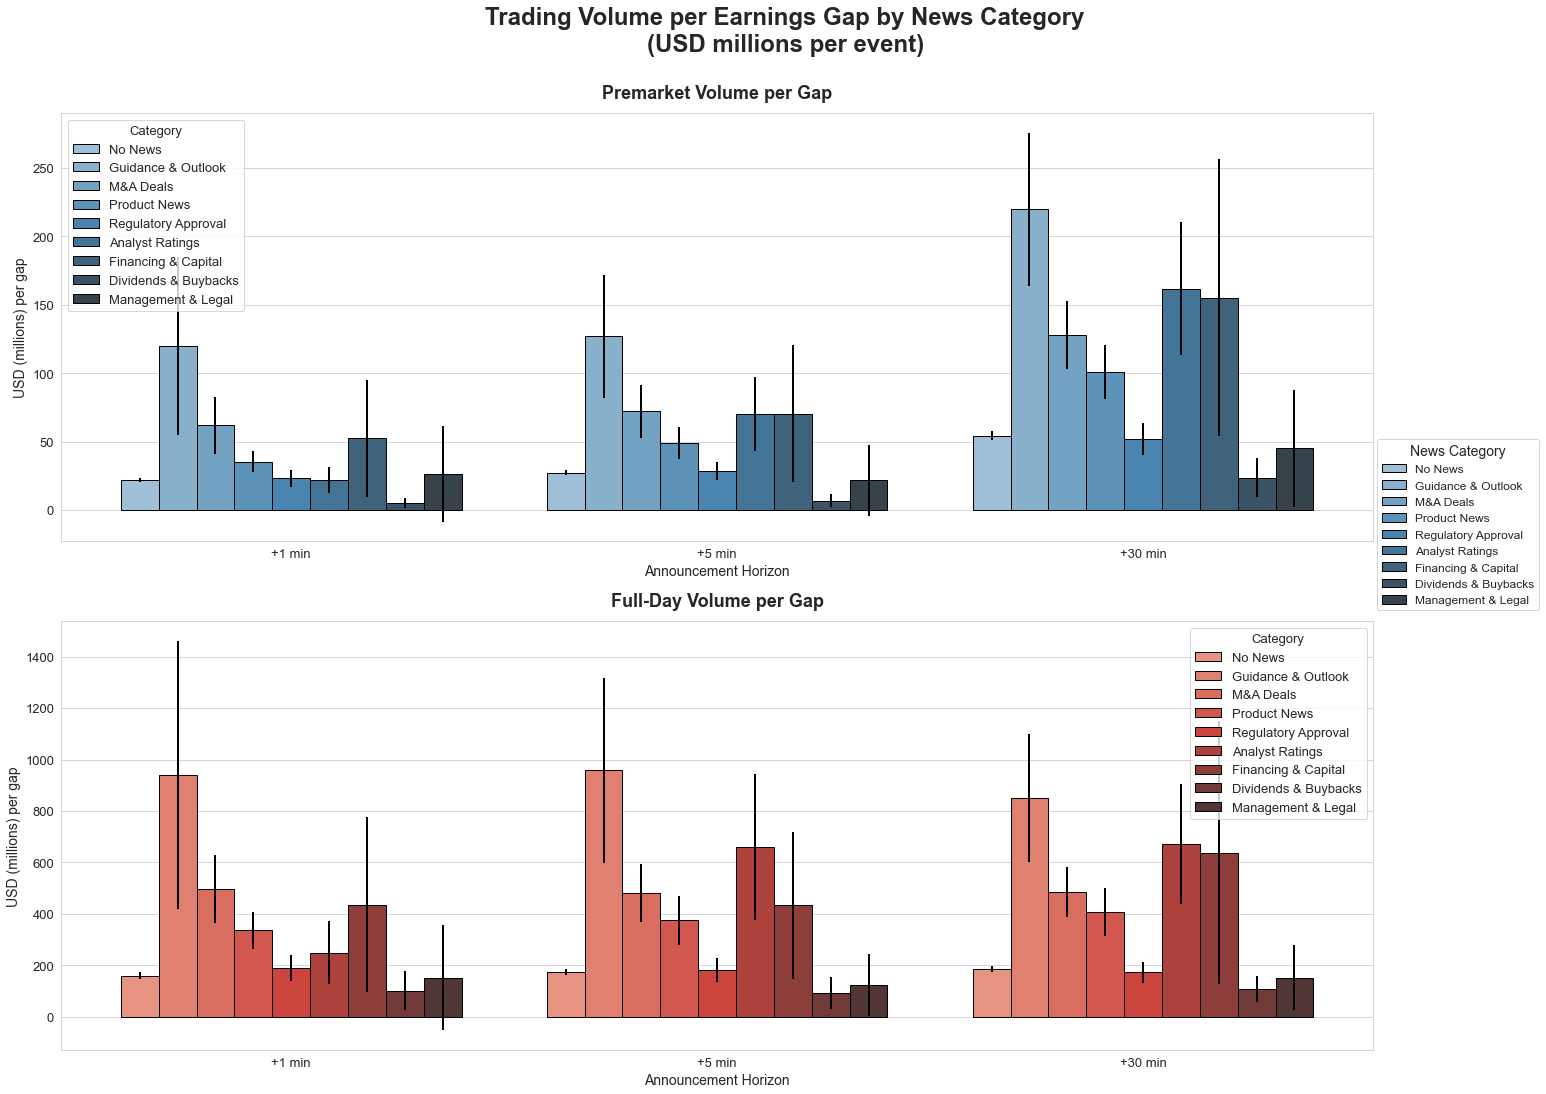

HOTOVO — volumes converted to USD millions with consistent CI.


In [7]:
# =============================================================================
# 2_PLOT_VOLUME_BY_CATEGORY_STRICT_FINAL_BOLD_CI_MILLIONS.py
# → Bold bar plots for strict hierarchical category volume analysis
# → Premarket vs Full-Day, values in USD millions
# → CI lines drawn from std & N
# → One common legend on the right
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# === LOAD DATA ===
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\volume_analysis_by_category_strict")
df = pd.read_csv(BASE / "volume_analysis_by_category_strict.csv")

# === SCALE TO MILLIONS ===
SCALE = 1_000_000
df["Premarket_USD_mean"] /= SCALE
df["Premarket_USD_std"]  /= SCALE
df["Full_Day_USD_mean"]  /= SCALE
df["Full_Day_USD_std"]   /= SCALE

# === PRETTY CATEGORY NAMES ===
name_map = {
    "No_news": "No News",
    "news_Guidance___Outlook_count": "Guidance & Outlook",
    "news_M&A___Deal_count": "M&A Deals",
    "news_Product_News_count": "Product News",
    "news_Regulatory_Approval_count": "Regulatory Approval",
    "news_Analyst___Rating_count": "Analyst Ratings",
    "news_Financing___Capital_count": "Financing & Capital",
    "news_Dividends___Buybacks_count": "Dividends & Buybacks",
    "news_Management___Legal_count": "Management & Legal",
}
df["Category"] = df["Category"].map(name_map).fillna(df["Category"])

# === ORDER CATEGORIES & HORIZONS ===
cat_order = [
    "No News", "Guidance & Outlook", "M&A Deals", "Product News", "Regulatory Approval",
    "Analyst Ratings", "Financing & Capital", "Dividends & Buybacks", "Management & Legal"
]
horizon_order = ["+1 min", "+5 min", "+30 min"]

df["Category"] = pd.Categorical(df["Category"], categories=cat_order, ordered=True)
df["Horizon"] = pd.Categorical(df["Horizon"], categories=horizon_order, ordered=True)

# === SETTINGS ===
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 13})

fig, axes = plt.subplots(2, 1, figsize=(22, 16))
fig.suptitle(
    "Trading Volume per Earnings Gap by News Category\n(USD millions per event)",
    fontsize=24,
    fontweight='bold',
    y=0.95
)

def plot_volume_with_ci(ax, y_col_mean, y_col_std, title, palette, show_legend=False):

    sns.barplot(
        data=df,
        x="Horizon",
        y=y_col_mean,
        hue="Category",
        palette=palette,
        ax=ax,
        ci=None,
        edgecolor="black"
    )

    # --- Draw CI lines manually: mean ± 1.96*(std/sqrt(N)) ---
    for i, horizon in enumerate(horizon_order):
        for j, cat in enumerate(cat_order):
            sub = df[(df["Horizon"] == horizon) & (df["Category"] == cat)]
            if sub.empty:
                continue

            mean = sub[y_col_mean].values[0]
            std = sub[y_col_std].values[0]
            n = sub["N"].values[0]

            if n <= 0:
                continue

            se = std / np.sqrt(n)
            ci_low = mean - 1.96 * se
            ci_high = mean + 1.96 * se

            num_hue = len(cat_order)
            total_width = 0.8
            bar_width = total_width / num_hue
            x = i - total_width / 2 + j * bar_width + bar_width / 2

            ax.vlines(x, ci_low, ci_high, color="black", linewidth=2)

    ax.set_title(title, fontsize=18, fontweight='bold', pad=15)
    ax.set_ylabel("USD (millions) per gap", fontsize=14)
    ax.set_xlabel("Announcement Horizon", fontsize=14)

    if not show_legend:
        ax.legend_.remove()

# --- Premarket ---
plot_volume_with_ci(
    axes[0],
    y_col_mean="Premarket_USD_mean",
    y_col_std="Premarket_USD_std",
    title="Premarket Volume per Gap",
    palette="Blues_d",
    show_legend=True
)

# --- Full-Day ---
plot_volume_with_ci(
    axes[1],
    y_col_mean="Full_Day_USD_mean",
    y_col_std="Full_Day_USD_std",
    title="Full-Day Volume per Gap",
    palette="Reds_d",
    show_legend=True
)

# === SINGLE LEGEND ON THE RIGHT ===
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="News Category",
    loc="center right",
    bbox_to_anchor=(0.98, 0.5),
    fontsize=12,
    title_fontsize=14,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.88, 0.95])

# === SAVE ===
plt.savefig(BASE / "VOLUME_BY_CATEGORY_STRICT_BOLD_CI_MILLIONS.png", dpi=300, bbox_inches='tight')
plt.savefig(BASE / "VOLUME_BY_CATEGORY_STRICT_BOLD_CI_MILLIONS.pdf", bbox_inches='tight')
plt.show()

print("HOTOVO — volumes converted to USD millions with consistent CI.")


In [70]:
final

,Category,Horizon,N,Premarket_USD_mean,Full_Day_USD_mean,Premarket_USD_median,Full_Day_USD_median,Premarket_USD_std,Full_Day_USD_std
0,No_news,+1 min,9475,2.165645e+07,1.593921e+08,4.806996e+06,2.220711e+07,7.380717e+07,6.218826e+08
1,No_news,+30 min,13913,5.445935e+07,1.872245e+08,1.006487e+07,2.529808e+07,1.792477e+08,7.030284e+08
2,No_news,+5 min,12335,2.744078e+07,1.733117e+08,4.914911e+06,2.039861e+07,9.692555e+07,6.786944e+08
3,news_Analyst___Rating_count,+1 min,48,2.213140e+07,2.491262e+08,5.963088e+06,5.361711e+07,3.394954e+07,4.331664e+08
4,news_Analyst___Rating_count,+30 min,162,1.619117e+08,6.718223e+08,3.225953e+07,1.165616e+08,3.144678e+08,1.515849e+09
5,news_Analyst___Rating_count,+5 min,107,7.045888e+07,6.606706e+08,1.586784e+07,9.398430e+07,1.425475e+08,1.503934e+09
6,news_Dividends___Buybacks_count,+1 min,11,5.058708e+06,1.002692e+08,2.917300e+06,2.546594e+07,6.241386e+06,1.285791e+08
7,news_Dividends___Buybacks_count,+30 min,20,2.366144e+07,1.072659e+08,9.062380e+06,3.768543e+07,3.293795e+07,1.155920e+08
8,news_Dividends___Buybacks_count,+5 min,14,6.822057e+06,9.231719e+07,3.610148e+06,2.973036e+07,9.064755e+06,1.180285e+08
9,news_Financing___Capital_count,+1 min,51,5.257883e+07,4.355594e+08,1.045897e+07,8.537500e+07,1.560301e+08,1.244051e+09


In [72]:
# =============================================================================
# 1_GAP_PERCENT_ANALYSIS_BY_CATEGORY_STRICT_FROM_OHLC.py
# → Computes average price gap (%) per earnings event by strict hierarchical category
# → Premarket gap % from previous close → open
# → Full-day gap % from previous close → close
# → Uses mega_final ONLY for news/category columns
# =============================================================================

import pandas as pd
from pathlib import Path

# ---------------- CONFIG ----------------
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME")
SIG_GAPS_DIR = BASE / "significant_gaps"
OHLC_FILE = BASE / "daily_ohlc_unfiltered.csv"
NEWS_FINAL_DIR = BASE / "news_final"
OUT_DIR = BASE / "gap_percent_analysis_by_category_strict"
OUT_DIR.mkdir(exist_ok=True)

# Horizons and corresponding sig gaps filenames
HORIZONS = {
    "plus1": "Sig30_prem1_main.csv",
    "plus5": "Sig30_prem5_main.csv",
    "plus30": "Sig30_prem30main.csv"
}

# Premarket columns in sig gaps (not used but kept for compatibility)
PREMARKET_COLS = {
    "plus1": "Premarket+1_USD",
    "plus5": "Premarket+5_USD",
    "plus30": "Premarket+30_USD"
}

# Correct mapping horizon → mega_final file
MEGA_FILES = {
    "plus1": "mega_final1.csv",
    "plus5": "mega_final5.csv",
    "plus30": "mega_final30.csv"
}

# Strict hierarchical order
HIERARCHY_ORDER = [
    "news_Guidance___Outlook_count",
    "news_M&A___Deal_count",
    "news_Product_News_count",
    "news_Regulatory_Approval_count",
    "news_Analyst___Rating_count",
    "news_Financing___Capital_count",
    "news_Management___Legal_count",
    "news_Dividends___Buybacks_count"
]

def pick_category(row):
    for cat in HIERARCHY_ORDER:
        if row.get(cat, 0) > 0:
            return cat
    return "No_news"

# ---------------- LOAD OHLC DATA ----------------
ohlc = pd.read_csv(OHLC_FILE, parse_dates=["Date"], low_memory=False)
ohlc["symbol"] = ohlc["Ticker"].str.upper()
ohlc = ohlc.sort_values(["symbol", "Date"])

# Previous close for gap calculation
ohlc["prev_close"] = ohlc.groupby("symbol")["Close"].shift(1)
ohlc["Premarket_pct"] = (ohlc["Open"] - ohlc["prev_close"]) / ohlc["prev_close"] * 100
ohlc["Full_Day_pct"] = (ohlc["Close"] - ohlc["prev_close"]) / ohlc["prev_close"] * 100

ohlc = ohlc[["symbol", "Date", "Premarket_pct", "Full_Day_pct"]]

results = []

# ---------------- PROCESS EACH HORIZON ----------------
for horizon, sig_file in HORIZONS.items():
    print(f"\nProcessing horizon: {horizon} ({sig_file})")
    
    sig_path = SIG_GAPS_DIR / sig_file
    if not sig_path.exists():
        print(f"Missing file: {sig_path}")
        continue
    
    # Load sig gaps CSV (for list of events)
    sig_df = pd.read_csv(sig_path, parse_dates=["Date"], low_memory=False)
    sig_df["symbol"] = sig_df["symbol"].str.upper()
    
    # Only keep symbol + date for merging with OHLC
    sig_df = sig_df[["symbol", "Date"]].copy()
    
    # Load mega_final for news/category columns only
    mega_file = NEWS_FINAL_DIR / MEGA_FILES[horizon]
    if not mega_file.exists():
        print(f"Missing mega_final: {mega_file}")
        continue
    
    mega_df = pd.read_csv(mega_file, parse_dates=["Date"], low_memory=False)
    mega_df["symbol"] = mega_df["symbol"].str.upper()
    
    category_cols = [c for c in HIERARCHY_ORDER]
    df_merge = mega_df[["symbol", "Date"] + category_cols].copy()
    
    # Merge sig gaps with mega_final for category assignment
    df = sig_df.merge(df_merge, on=["symbol", "Date"], how="left")
    
    # Assign strict hierarchical category
    df["Category"] = df.apply(pick_category, axis=1)
    
    # Merge with OHLC to get Premarket_pct and Full_Day_pct
    df = df.merge(ohlc, on=["symbol", "Date"], how="left")
    
    # Fill missing gaps with 0
    df["Premarket_pct"] = df["Premarket_pct"].fillna(0)
    df["Full_Day_pct"] = df["Full_Day_pct"].fillna(0)
    
    # Group by strict category and calculate statistics
    for cat, g in df.groupby("Category"):
        n = len(g)
        if n == 0:
            continue
        
        results.append({
            "Category": cat,
            "Horizon": horizon.replace("plus", "+").replace("1","1 min")
                                .replace("5","5 min").replace("30","30 min"),
            "N": n,
            "Premarket_pct_mean": g["Premarket_pct"].mean(),
            "Full_Day_pct_mean": g["Full_Day_pct"].mean(),
            "Premarket_pct_median": g["Premarket_pct"].median(),
            "Full_Day_pct_median": g["Full_Day_pct"].median(),
            "Premarket_pct_std": g["Premarket_pct"].std(),
            "Full_Day_pct_std": g["Full_Day_pct"].std()
        })

# ---------------- SAVE FINAL TABLE ----------------
final = pd.DataFrame(results)
final = final.sort_values(["Category", "Horizon"]).reset_index(drop=True)
out_file = OUT_DIR / "gap_percent_analysis_by_category_strict_from_ohlc.csv"
final.to_csv(out_file, index=False, encoding="utf-8-sig")

print(f"\nDONE! Table saved: {out_file}")
print(f"Total rows: {len(final)}")



Processing horizon: plus1 (Sig30_prem1_main.csv)

Processing horizon: plus5 (Sig30_prem5_main.csv)

Processing horizon: plus30 (Sig30_prem30main.csv)

DONE! Table saved: C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\gap_percent_analysis_by_category_strict\gap_percent_analysis_by_category_strict_from_ohlc.csv
Total rows: 27


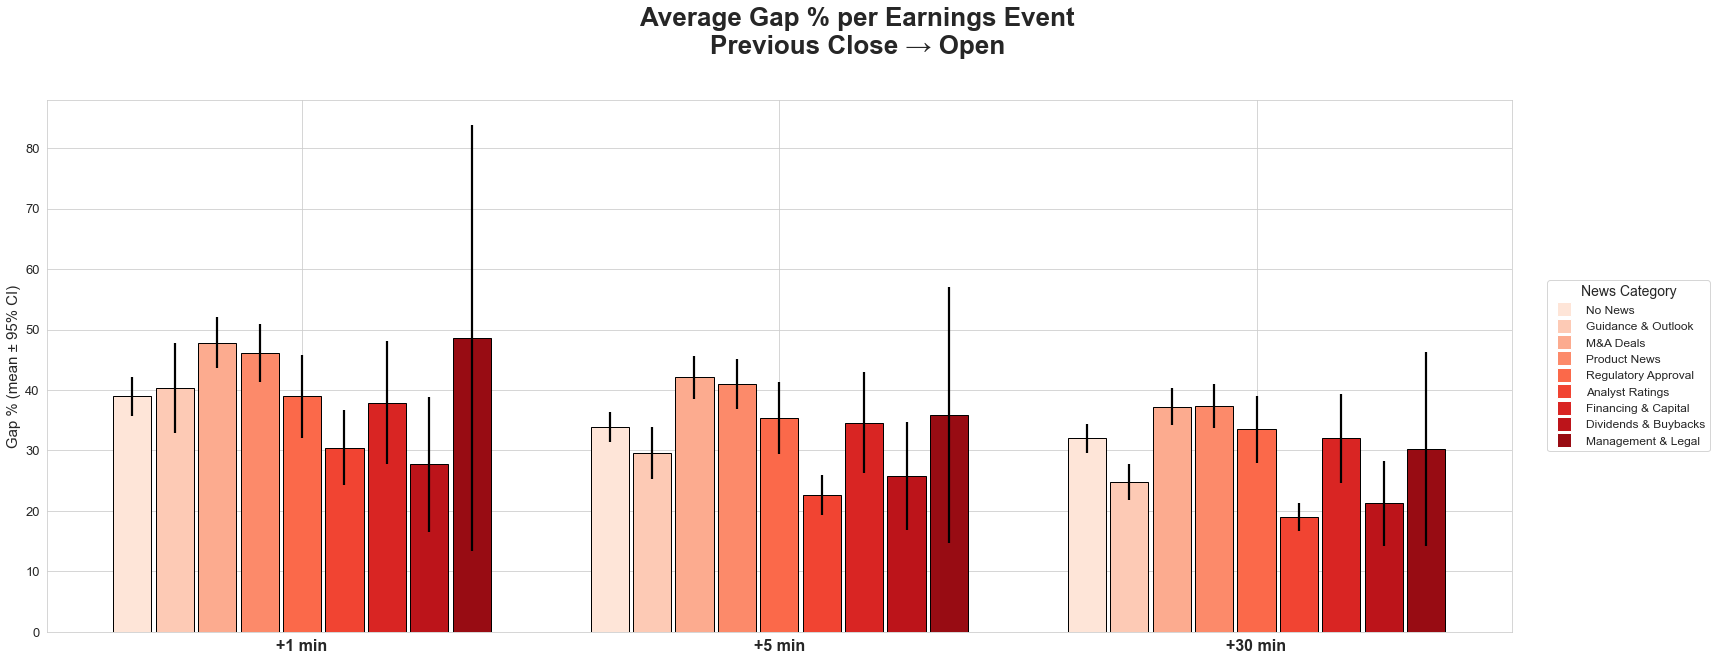

DONE — nested horizon blocks with category bars and CI lines.


In [79]:
# =============================================================================
# GAP_PERCENT_NESTED_BY_CATEGORY_AND_HORIZON_RED_WITH_CI.py
# → One chart
# → 3 thick horizon blocks (+1, +5, +30)
# → Nested category bars inside
# → Explicit 95% CI lines
# =============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path

# === LOAD DATA ===
BASE = Path(r"C:\Users\j-vas\1JUPYTERLAB\diplomka\MAIN_DATAFRAME\gap_percent_analysis_by_category_strict")
df = pd.read_csv(BASE / "gap_percent_analysis_by_category_strict_from_ohlc.csv")

# === CATEGORY SETUP ===
category_order_raw = [
    "No_news", "news_Guidance___Outlook_count", "news_M&A___Deal_count",
    "news_Product_News_count", "news_Regulatory_Approval_count",
    "news_Analyst___Rating_count", "news_Financing___Capital_count",
    "news_Dividends___Buybacks_count", "news_Management___Legal_count"
]

category_map = {
    "No_news": "No News",
    "news_Guidance___Outlook_count": "Guidance & Outlook",
    "news_M&A___Deal_count": "M&A Deals",
    "news_Product_News_count": "Product News",
    "news_Regulatory_Approval_count": "Regulatory Approval",
    "news_Analyst___Rating_count": "Analyst Ratings",
    "news_Financing___Capital_count": "Financing & Capital",
    "news_Dividends___Buybacks_count": "Dividends & Buybacks",
    "news_Management___Legal_count": "Management & Legal"
}

df = df.copy()
df["Category"] = df["Category"].map(category_map)

category_order = [category_map[c] for c in category_order_raw]
horizons = ["+1 min", "+5 min", "+30 min"]

# === COMPUTE CI ===
df["ci_low"]  = df["Premarket_pct_mean"] - 1.96 * df["Premarket_pct_std"] / np.sqrt(df["N"])
df["ci_high"] = df["Premarket_pct_mean"] + 1.96 * df["Premarket_pct_std"] / np.sqrt(df["N"])

# === PLOT SETTINGS ===
sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 13})

fig, ax = plt.subplots(figsize=(24, 9))
fig.suptitle(
    "Average Gap % per Earnings Event\nPrevious Close → Open",
    fontsize=26,
    fontweight="bold",
    y=1.02
)

# Red shades for categories
colors = sns.color_palette("Reds", n_colors=len(category_order))

# Geometry
group_width = 0.8        # width of one horizon block
bar_width   = group_width / len(category_order)
x_base = np.arange(len(horizons))

# === DRAW BARS ===
for h_i, horizon in enumerate(horizons):
    data_h = df[df["Horizon"] == horizon]

    for c_i, category in enumerate(category_order):
        row = data_h[data_h["Category"] == category]
        if row.empty:
            continue

        x = x_base[h_i] - group_width/2 + c_i*bar_width + bar_width/2

        mean = row["Premarket_pct_mean"].values[0]
        low  = row["ci_low"].values[0]
        high = row["ci_high"].values[0]

        # Bar
        ax.bar(
            x,
            mean,
            width=bar_width * 0.9,
            color=colors[c_i],
            edgecolor="black"
        )

        # CI line
        ax.vlines(
            x,
            low,
            high,
            color="black",
            linewidth=2.2
        )

# === AXES ===
ax.set_xticks(x_base)
ax.set_xticklabels(horizons, fontsize=16, fontweight="bold")
ax.set_ylabel("Gap % (mean ± 95% CI)", fontsize=15)
ax.ticklabel_format(style="plain", axis="y")

# === LEGEND (CATEGORIES ONLY) ===
handles = [
    plt.Line2D([0], [0], marker='s', color='w',
               markerfacecolor=colors[i], markersize=14,
               label=cat)
    for i, cat in enumerate(category_order)
]

ax.legend(
    handles=handles,
    title="News Category",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left",
    frameon=True,
    fontsize=12,
    title_fontsize=14
)

plt.tight_layout()
plt.savefig(BASE / "GAP_PERCENT_NESTED_BY_CATEGORY_AND_HORIZON.png", dpi=300, bbox_inches="tight")
plt.savefig(BASE / "GAP_PERCENT_NESTED_BY_CATEGORY_AND_HORIZON.pdf", bbox_inches="tight")
plt.show()

print("DONE — nested horizon blocks with category bars and CI lines.")


In [80]:
final

,Category,Horizon,N,Premarket_pct_mean,Full_Day_pct_mean,Premarket_pct_median,Full_Day_pct_median,Premarket_pct_std,Full_Day_pct_std
0,No_news,+1 min,9475,38.962006,33.666650,21.573604,16.129032,159.961190,160.815909
1,No_news,+30 min,13913,32.052318,30.827936,17.283951,16.442953,144.219715,153.751615
2,No_news,+5 min,12335,33.867784,30.111374,18.644068,15.146709,142.734090,142.963024
3,news_Analyst___Rating_count,+1 min,48,30.475740,34.035270,23.721408,20.697579,22.028559,43.184456
4,news_Analyst___Rating_count,+30 min,162,18.947104,22.497084,14.649258,16.806126,15.284992,26.961585
5,news_Analyst___Rating_count,+5 min,107,22.679299,25.716854,18.039625,17.591898,17.366283,31.904135
6,news_Dividends___Buybacks_count,+1 min,11,27.701156,49.611774,27.217523,40.684258,18.886167,43.641489
7,news_Dividends___Buybacks_count,+30 min,20,21.276121,36.720492,16.098195,30.242994,16.007459,36.133564
8,news_Dividends___Buybacks_count,+5 min,14,25.774334,45.850135,24.539431,35.369318,17.183092,39.065966
9,news_Financing___Capital_count,+1 min,51,37.893652,36.032463,24.196721,22.040816,37.093372,40.863726
